In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install torch_geometric rdkit


In [ ]:
%cd /content/drive/MyDrive/DrugPropertyProject/TraGT/

/content/drive/MyDrive/DrugPropertyProject/TraGT


In [ ]:
import torch
import numpy as np
from rdkit import Chem
from collections import defaultdict
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split


In [ ]:
#....................new................
def load_data_long(dataset, device):
    atom_types = [
    1,   # H
    5,   # B
    6,   # C
    7,   # N
    8,   # O
    9,   # F
    14,  # Si
    15,  # P
    16,  # S
    17,  # Cl
    34,  # Se
    35,  # Br
    53,  # I
    11,  # Na
    12,  # Mg
    13,  # Al
    19,  # K
    20,  # Ca
    25,  # Mn
    26,  # Fe
    27,  # Co
    28,  # Ni
    29,  # Cu
    30,  # Zn
    33,  # As
    42,  # Mo
    50,  # Sn
    78,  # Pt
    80   # Hg
]

    mole_dict = {atom: idx for idx, atom in enumerate(atom_types)}
    UNK = len(mole_dict)
    #mole_dict = {1: "H", 2: "He", 3: "Li", 4: "Be", 5: "B", 6: "C", 7: "N", 8: "O", 9: "F", 10: " Ne",
    #            11: "Na", 12:"Mg", 13: "Al", 14:"Si", 15:"P", 16: "S", 17: "Cl", 18:"Ar", 19:"K", 20:"Ca", 22:"Ti", 24:"Cr", 25:"Mn", 26:"Fe", 28:"Ni",
    #            29:"Cu", 31:"Ga", 32:"Ge", 34:"Se", 35:"Br", 40:"Zr", 44:"Ru", 45:"Rh", 46:"Pd", 47:"Ag", 50:"Sn", 51:"Sb", 52:"Te", 53: "I", 65:"Tb", 75:"Re", 77:"Ir", 78:"Pt", 79:"Au", 80:"Hg",
     #           81:"Tl", 82:"Pb", 83:"Bi"}

    pair_list = ["Br", "Cl", "Si", "Na", "Ca", "Ge", "Cu", "Au", "Sn", "Tb", "Pt", "Re", "Ru", "Bi", "Li", "Fe", "Sb", "Hg","Pb", "Se", "Ag","Cr","Pd","Ga","Mg","Ni","Ir","Rh","Te","Ti","Al","Zr","Tl"]
    data_file = f"/content/drive/MyDrive/DrugPropertyProject/TraGT/datasets/{dataset}_train.txt"
    file = open(data_file, "r")
    node_types = set()
    label_types = set()
    tr_len = 0
    for line in file:
        tr_len += 1
        parts = line.strip().split("\t")

        if len(parts) < 3:
          continue

        smiles = parts[1]
        label = int(parts[2])
        #smiles = line.split("\t")[1]
        #label = line.split("\t")[2][:-1]
        i = 0
        s = []
        while i < len(smiles):
            if i < len(smiles)-1 and (smiles[i] + smiles[i+1]) in pair_list:
                s.append(smiles[i] + smiles[i+1])
                i += 2
            else:
                s.append(smiles[i].upper())
                i += 1
        node_types |= set(s)
        label_types.add(label)
    file.close()

    te_len = 0
    data_file = f"/content/drive/MyDrive/DrugPropertyProject/TraGT/datasets/{dataset}_test.txt"
    file = open(data_file, "r")
    for line in file:
        te_len += 1
        parts = line.strip().split("\t")

        if len(parts) < 3:
          continue

        smiles = parts[1]
        label = int(parts[2])
#smiles = line.split("\t")[1]
        #label = line.split("\t")[2][:-1]
        i = 0
        s = []
        while i < len(smiles):
            if i < len(smiles)-1 and (smiles[i] + smiles[i+1]) in pair_list:
                s.append(smiles[i] + smiles[i+1])
                i += 2
            else:
                s.append(smiles[i].upper())
                i += 1
        node_types |= set(s)
        label_types.add(label)
    file.close()

    #print(tr_len)
    #print(te_len)

    node2index = {n: i for i, n in enumerate(node_types)}
    label2index = {l: i for i, l in enumerate(label_types)}

    #print(node2index)
    #print(label2index)

    data_file = f"/content/drive/MyDrive/DrugPropertyProject/TraGT/datasets/{dataset}_train.txt"
    file = open(data_file, "r")
    train_adjlists = []
    train_features = []
    train_sequence = []
    train_fg = []
    train_labels = torch.zeros(tr_len)
    for line in file:
        parts = line.strip().split("\t")

        if len(parts) < 3:
          continue

        smiles = parts[1]
        label = int(parts[2])
        #smiles = line.split("\t")[1]
        fg = extract_functional_groups(smiles)
        #label = line.split("\t")[2][:-1]
        mol = Chem.MolFromSmiles(smiles)
        graph_nodes = []
        for atom in mol.GetAtoms():
            #graph_nodes.append(mole_dict[atom.GetAtomicNum()], UNK)
            graph_nodes.append(mole_dict.get(atom.GetAtomicNum(), UNK))
        # print(graph_nodes)
        i = 0
        s = 0
        while i < len(smiles):
            if i < len(smiles)-1 and (smiles[i] + smiles[i+1]) in pair_list:
                i += 2
            else:
                i += 1
            s += 1

        feature = torch.zeros(s, len(node_types))

        map = {}
        se_num = 0
        gr_num = 0
        i = 0
        smiles_seq = []
        while i < len(smiles):
            this_str = smiles[i]
            if i < len(smiles)-1 and (smiles[i] + smiles[i+1]) in pair_list:
                this_str = smiles[i] + smiles[i+1]
                i += 2
            else:
                this_str = this_str.upper()
                i += 1
            smiles_seq.append(node2index[this_str])
            if this_str in graph_nodes and this_str == mole_dict[mol.GetAtoms()[gr_num].GetAtomicNum()]:
                map[gr_num] = se_num
                gr_num += 1
            feature[se_num, node2index[this_str]] = 1
            se_num += 1


        for new_idx, atom in enumerate(mol.GetAtoms()):
            old_idx = atom.GetIdx()
            atomic_num = atom.GetAtomicNum()

            graph_nodes.append(mole_dict.get(atomic_num, UNK))
            map[old_idx] = new_idx

        #adj_list = defaultdict(list)
        adj_list = {}

        for i in range(len(graph_nodes)):
            adj_list[i] = []
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            # print(i,j)
            typ = bond.GetBondType()
            adj_list[map[i]].append(map[j])
            adj_list[map[j]].append(map[i])
            if typ == Chem.rdchem.BondType.DOUBLE:
                adj_list[map[i]].append(map[j])
                adj_list[map[j]].append(map[i])
            elif typ == Chem.rdchem.BondType.TRIPLE:
                adj_list[map[i]].append(map[j])
                adj_list[map[j]].append(map[i])
                adj_list[map[i]].append(map[j])
                adj_list[map[j]].append(map[i])

        # train_labels[len(train_adjlists)]= int(label2index[label])
        train_labels[len(train_adjlists)]= int(label)
        train_adjlists.append(adj_list)
        train_features.append(torch.FloatTensor(feature).to(device))
        train_sequence.append(torch.tensor(smiles_seq))
        train_fg.append(fg)
    file.close()

    data_file = f"/content/drive/MyDrive/DrugPropertyProject/TraGT/datasets/{dataset}_test.txt"
    file = open(data_file, "r")
    test_adjlists = []
    test_features = []
    test_sequence = []
    test_fg = []
    test_labels = np.zeros(te_len)
    for line in file:
        parts = line.strip().split("\t")

        if len(parts) < 3:
          continue

        smiles = parts[1]
        label = int(parts[2])
        #smiles = line.split("\t")[1]
        # print(smiles)
        fg = extract_functional_groups(smiles)
        #label = line.split("\t")[2][:-1]
        mol = Chem.MolFromSmiles(smiles)
        graph_nodes = []
        for atom in mol.GetAtoms():
            #graph_nodes.append(mole_dict[atom.GetAtomicNum()])
            graph_nodes.append(mole_dict.get(atom.GetAtomicNum(), UNK))
        # print(graph_nodes)
        i = 0
        s = 0
        while i < len(smiles):
            if i < len(smiles)-1 and (smiles[i] + smiles[i+1]) in pair_list:
                i += 2
            else:
                i += 1
            s += 1

        feature = torch.zeros(s, len(node_types))

        map = {}
        se_num = 0
        gr_num = 0
        i = 0
        smiles_seq = []
        while i < len(smiles):
            this_str = smiles[i]
            if i < len(smiles)-1 and (smiles[i] + smiles[i+1]) in pair_list:
                this_str = smiles[i] + smiles[i+1]
                i += 2
            else:
                this_str = this_str.upper()
                i += 1
            smiles_seq.append(node2index[this_str])
            if this_str in graph_nodes and this_str == mole_dict[mol.GetAtoms()[gr_num].GetAtomicNum()]:
                map[gr_num] = se_num
                gr_num += 1
            feature[se_num, node2index[this_str]] = 1
            se_num += 1

        for new_idx, atom in enumerate(mol.GetAtoms()):
            old_idx = atom.GetIdx()
            atomic_num = atom.GetAtomicNum()

            graph_nodes.append(mole_dict.get(atomic_num, UNK))
            map[old_idx] = new_idx

        adj_list = {}

        for i in range(len(graph_nodes)):
            adj_list[i] = []
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            # print(i,j)
            typ = bond.GetBondType()
            adj_list[map[i]].append(map[j])
            adj_list[map[j]].append(map[i])
            if typ == Chem.rdchem.BondType.DOUBLE:
                adj_list[map[i]].append(map[j])
                adj_list[map[j]].append(map[i])
            elif typ == Chem.rdchem.BondType.TRIPLE:
                adj_list[map[i]].append(map[j])
                adj_list[map[j]].append(map[i])
                adj_list[map[i]].append(map[j])
                adj_list[map[j]].append(map[i])

        # test_labels[len(test_adjlists)] = int(label2index[label])
        test_labels[len(test_adjlists)] = int(label)
        test_adjlists.append(adj_list)
        test_features.append(torch.FloatTensor(feature).to(device))
        test_sequence.append(torch.tensor(smiles_seq))
        test_fg.append(fg)
    file.close()

    #train_data = {}
    train_data_full = {}
    train_data_full['adj_lists'] = train_adjlists
    train_data_full['features'] = train_features
    padded_train_sequence = []
    for seq in train_sequence:
        padded_seq = torch.nn.functional.pad(seq, (0, 100 - len(seq)), 'constant', 0)
        padded_train_sequence.append(padded_seq)

    train_data_full['sequence'] = padded_train_sequence
    train_data_full['fg'] = train_fg

    test_data = {}
    test_data['adj_lists'] = test_adjlists
    test_data['features'] = test_features

    padded_test_sequence = []
    for seq in test_sequence:
        padded_seq = torch.nn.functional.pad(seq, (0, 100 - len(seq)), 'constant', 0)
        padded_test_sequence.append(padded_seq)

    test_data['sequence'] = padded_test_sequence
    test_data['fg'] = test_fg
    num_samples = len(train_data_full['adj_lists'])

    indices = np.arange(num_samples)

    train_indices, val_indices = train_test_split(
        indices,
        test_size=0.1,
        random_state=42,
        stratify=train_labels.cpu().numpy()
    )

    def split_data(data, indices):
        split_dict = {}
        split_dict['adj_lists'] = [data['adj_lists'][i] for i in indices]
        split_dict['features'] = [data['features'][i] for i in indices]
        split_dict['sequence'] = [data['sequence'][i] for i in indices]
        split_dict['fg'] = [data['fg'][i] for i in indices]
        return split_dict

    train_data = split_data(train_data_full, train_indices)
    val_data = split_data(train_data_full, val_indices)

    train_labels_split = train_labels[train_indices]
    val_labels = train_labels[val_indices]

    print("Full train size:", len(train_labels))
    print("Train size:", len(train_labels_split))
    print("Validation size:", len(val_labels))
    print("Test size:", len(test_labels))

    return train_data, train_labels_split, val_data, val_labels, test_data, test_labels



class CustomDataset(Dataset):
    def __init__(self, data_list, sequence_list, fg_list):
        self.data_list = data_list
        self.sequence_list = sequence_list
        self.fg_list = fg_list

    def __getitem__(self, index):
        data = self.data_list[index]
        sequence = self.sequence_list[index]
        fg = self.fg_list[index]

        return data, sequence, fg

    def __len__(self):
        return len(self.data_list)

def adj_list_to_adj_matrix(adj_list):
    num_nodes = max(adj_list.keys()) + 1
    adj_matrix = torch.zeros((num_nodes, num_nodes), dtype=torch.float)
    for node, neighbors in adj_list.items():
        for neighbor in neighbors:
            adj_matrix[node][neighbor] = 1.0
            adj_matrix[neighbor][node] = 1.0
    return adj_matrix

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import TransformerConv

class GCNConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, heads, concat=True):
        super(GCNConvLayer, self).__init__()
        self.conv = TransformerConv(
            in_channels,
            out_channels,
            heads=heads,
            concat=concat
        )

    def forward(self, x, edge_index):
        return self.conv(x, edge_index)


class Graph_Transformer(nn.Module):
    def __init__(self, in_channels, hidden_channels, embed_dim, heads, dropout_rate=0.3):
        super(Graph_Transformer, self).__init__()

        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

        # First layer: keep concat=True
        self.conv1 = GCNConvLayer(
            in_channels,
            hidden_channels,
            heads,
            concat=True
        )

        # Second layer
        self.conv2 = GCNConvLayer(
            hidden_channels * heads,
            embed_dim,
            heads=1,
            concat=False
        )

        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, data):
        x = data.x.to(self.device)
        edge_index = data.edge_index.to(self.device)

        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)

        # Global mean pooling (your version)
        x = x.mean(dim=0, keepdim=True)

        return x

In [ ]:
import torch
import torch.nn as nn


class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_encoder_layers=3,
                 dim_feedforward=512, max_length=100, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_length, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers
        )

    def forward(self, sequence):
        if sequence.dim() == 1:
            sequence = sequence.unsqueeze(0)

        sequence = sequence.long()

        batch_size, seq_len = sequence.shape

        positions = torch.arange(seq_len, device=sequence.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(sequence) + self.pos_embedding(positions)

        padding_mask = sequence.eq(0)

        x = self.transformer_encoder(
            x,
            src_key_padding_mask=padding_mask
        )

        mask = (~padding_mask).float().unsqueeze(-1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        return x

In [ ]:
from rdkit import Chem
import torch
import torch.nn as nn

FUNCTIONAL_GROUPS = {
    "alcohol": "[OX2H]",
    "phenol": "c[OX2H]",
    "amine_primary": "[NX3;H2]",
    "amine_secondary": "[NX3;H1]",
    "amine_tertiary": "[NX3;H0]",
    "amide": "C(=O)N",
    "carboxylic_acid": "C(=O)[OH]",
    "ester": "C(=O)O[#6]",
    "ether": "[OD2]([#6])[#6]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "ketone": "[#6][CX3](=O)[#6]",
    "nitro": "[NX3](=O)=O",
    "halide": "[F,Cl,Br,I]",
    "thiol": "[SX2H]",
    "thioether": "[SX2]([#6])[#6]",
    "sulfonamide": "S(=O)(=O)N",
    "sulfone": "S(=O)(=O)[#6]",
    "phosphate": "P(=O)(O)(O)",
    "alkene": "C=C",
    "alkyne": "C#C",
    "aromatic": "a",
    "benzene_ring": "c1ccccc1",
    "nitrile": "C#N",
}

FG_PATTERNS = {
    name: Chem.MolFromSmarts(smarts)
    for name, smarts in FUNCTIONAL_GROUPS.items()
}

def extract_functional_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return torch.zeros(len(FG_PATTERNS), dtype=torch.float)

    fg_vector = [
        int(mol.HasSubstructMatch(pattern))
        for pattern in FG_PATTERNS.values()
    ]

    return torch.tensor(fg_vector, dtype=torch.float)

In [ ]:
class FunctionalGroupEmbedding(nn.Module):
    def __init__(self, fg_input_dim, embed_dim=128, dropout_rate=0.3):
        super(FunctionalGroupEmbedding, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(fg_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, embed_dim),
            nn.ReLU()
        )

    def forward(self, fg):
        if fg.dim() == 1:
            fg = fg.unsqueeze(0)

        return self.fc(fg)

In [ ]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, dropout=0.4):
        super(CrossAttentionFusion, self).__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query_emb, context_emb):
        # query_emb   : [B, 128]
        # context_emb : [B, N, 128]

        query = query_emb.unsqueeze(1)      # [B, 1, 128]

        attn_out, attn_weights = self.attn(
            query=query,
            key=context_emb,
            value=context_emb
        )

        out = self.norm(query + self.dropout(attn_out))

        return out.squeeze(1), attn_weights

In [ ]:
class FusionModel(nn.Module):
    def __init__(
        self,
        graph_model,
        sequence_model=None,
        fg_encoder=None,
        embed_dim=128,
        model_option=2
    ):
        super(FusionModel, self).__init__()

        self.graph_model = graph_model
        self.sequence_model = sequence_model
        self.fg_encoder = fg_encoder
        self.model_option = model_option

        self.cross_attention = CrossAttentionFusion(
            embed_dim=embed_dim,
            num_heads=4,
            dropout=0.4
        )

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, graph_data, sequence_inputs=None, fg=None):

        graph_emb = self.graph_model(graph_data)

        if self.model_option == 0:
            # Graph + SMILES
            smiles_emb = self.sequence_model(sequence_inputs)

            # Query = graph, Key/Value = SMILES
            context = smiles_emb.unsqueeze(1)

            fused, attn_weights = self.cross_attention(
                query_emb=graph_emb,
                context_emb=context
            )

        elif self.model_option == 1:
            # Graph + FG
            fg_emb = self.fg_encoder(fg)

            # Query = graph, Key/Value = FG
            context = fg_emb.unsqueeze(1)

            fused, attn_weights = self.cross_attention(
                query_emb=graph_emb,
                context_emb=context
            )

        elif self.model_option == 2:
            # Graph + SMILES + FG
            smiles_emb = self.sequence_model(sequence_inputs)
            fg_emb = self.fg_encoder(fg)

            # Query = graph, Key/Value = [SMILES, FG]
            context = torch.stack(
                [smiles_emb, fg_emb],
                dim=1
            )   # [B, 2, 128]

            fused, attn_weights = self.cross_attention(
                query_emb=graph_emb,
                context_emb=context
            )

        else:
            raise ValueError("Invalid model_option. Use 0, 1, or 2.")

        logits = self.classifier(fused)

        return logits

Full train size: 5999
Train size: 5399
Validation size: 600
Test size: 2001
Train: [2678 2721]
Test : [1012  989]


/tmp/ipykernel_3660/1400702278.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(label, dtype=torch.float))
/tmp/ipykernel_3660/1400702278.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(label, dtype=torch.float))


Epoch 1/100, Epoch Accuracy: 81.7374
Saved model with accuracy train model with accuracy81.74% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_81.737.pth
Train AUC-ROC: 0.9025, Train F1 Score: 0.8154 , Train Precision: 0.8310, Train Recall: 0.8004

Epoch Val Accuracy : 88.5000
Val AUC-ROC: 0.9582, Val F1 Score: 0.8836, Val Precision: 0.9003, Val Recall: 0.8675

Saved best validation model from epoch 1 with validation accuracy 88.50% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_1_acc_88.500.pth


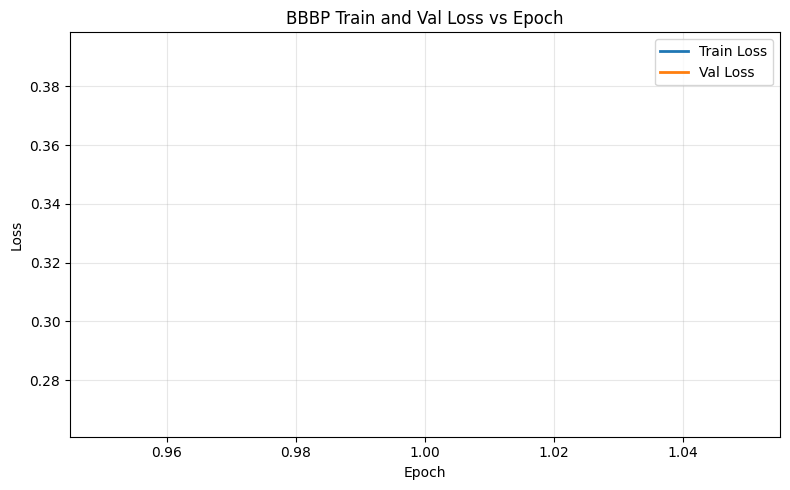

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 2/100, Epoch Accuracy: 89.1276
Saved model with accuracy train model with accuracy89.13% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_89.128.pth
Train AUC-ROC: 0.9530, Train F1 Score: 0.8891 , Train Precision: 0.9145, Train Recall: 0.8651

Epoch Val Accuracy : 88.5000
Val AUC-ROC: 0.9662, Val F1 Score: 0.8752, Val Precision: 0.9641, Val Recall: 0.8013

Saved best validation model from epoch 2 with validation accuracy 88.50% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_2_acc_88.500.pth


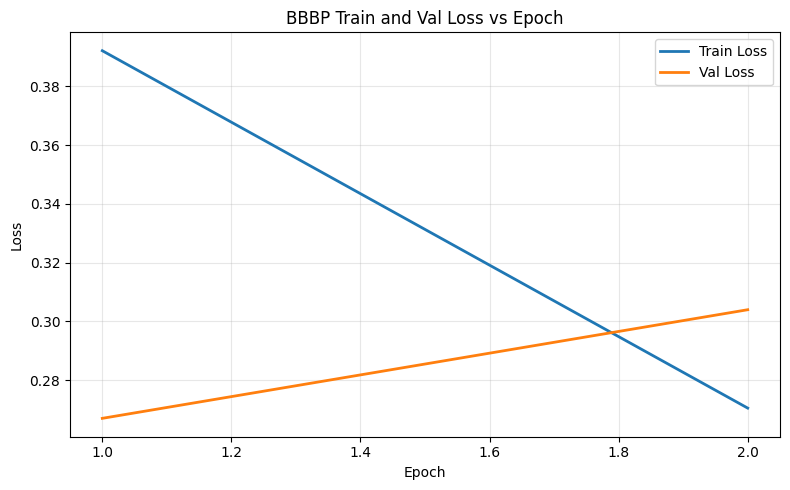

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 3/100, Epoch Accuracy: 90.4056
Saved model with accuracy train model with accuracy90.41% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_90.406.pth
Train AUC-ROC: 0.9627, Train F1 Score: 0.9025 , Train Precision: 0.9251, Train Recall: 0.8809

Epoch Val Accuracy : 90.3333
Val AUC-ROC: 0.9700, Val F1 Score: 0.8986, Val Precision: 0.9519, Val Recall: 0.8510

Saved best validation model from epoch 3 with validation accuracy 90.33% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_3_acc_90.333.pth


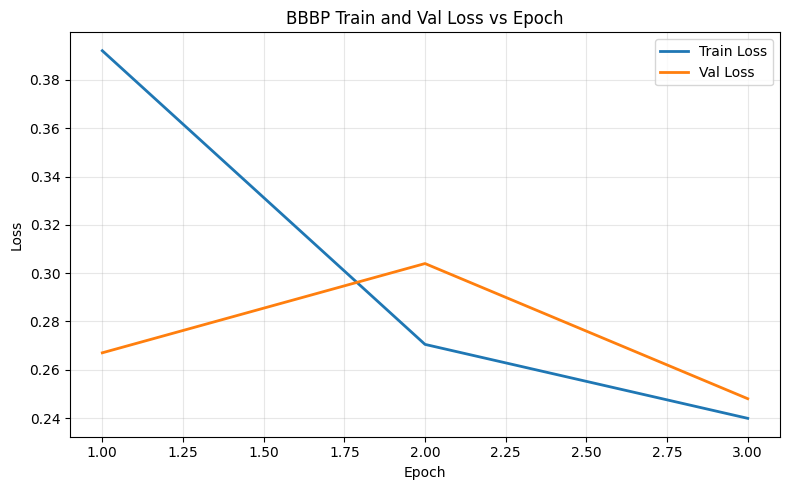

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 4/100, Epoch Accuracy: 91.5910
Saved model with accuracy train model with accuracy91.59% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_91.591.pth
Train AUC-ROC: 0.9685, Train F1 Score: 0.9145 , Train Precision: 0.9378, Train Recall: 0.8923

Epoch Val Accuracy : 89.6667
Val AUC-ROC: 0.9709, Val F1 Score: 0.8893, Val Precision: 0.9651, Val Recall: 0.8245



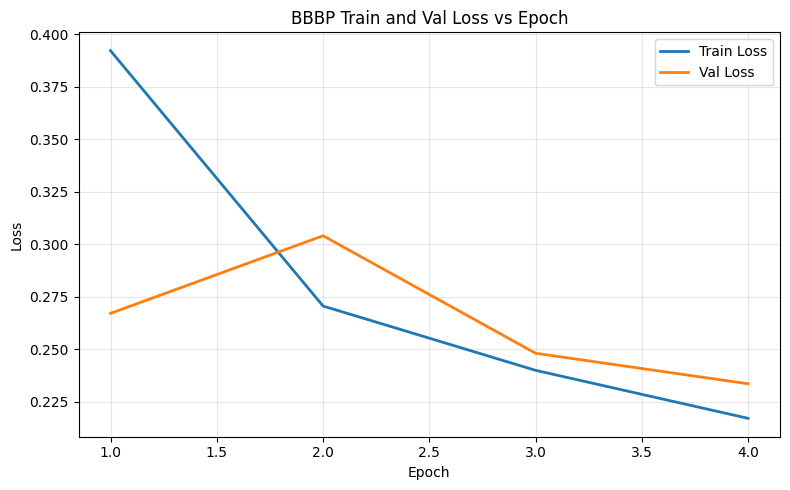

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 5/100, Epoch Accuracy: 91.7763
Saved model with accuracy train model with accuracy91.78% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_91.776.pth
Train AUC-ROC: 0.9706, Train F1 Score: 0.9166 , Train Precision: 0.9374, Train Recall: 0.8967

Epoch Val Accuracy : 89.1667
Val AUC-ROC: 0.9698, Val F1 Score: 0.8829, Val Precision: 0.9684, Val Recall: 0.8113



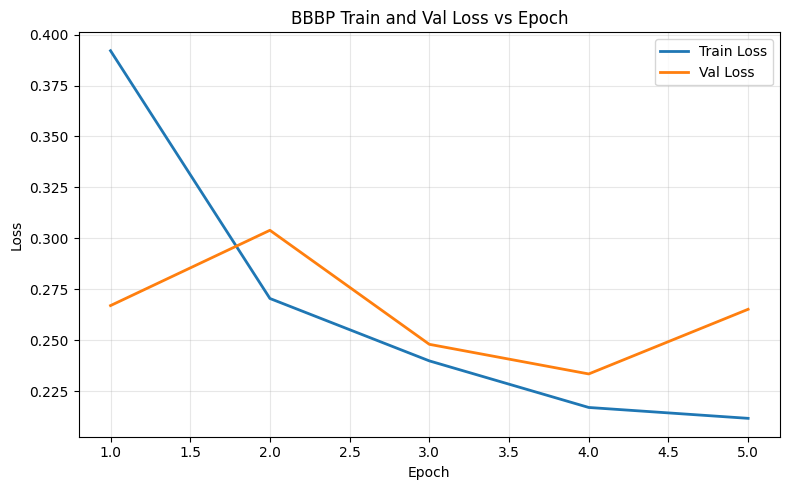

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 6/100, Epoch Accuracy: 92.1652
Saved model with accuracy train model with accuracy92.17% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_92.165.pth
Train AUC-ROC: 0.9739, Train F1 Score: 0.9207 , Train Precision: 0.9402, Train Recall: 0.9019

Epoch Val Accuracy : 89.8333
Val AUC-ROC: 0.9744, Val F1 Score: 0.8905, Val Precision: 0.9725, Val Recall: 0.8212



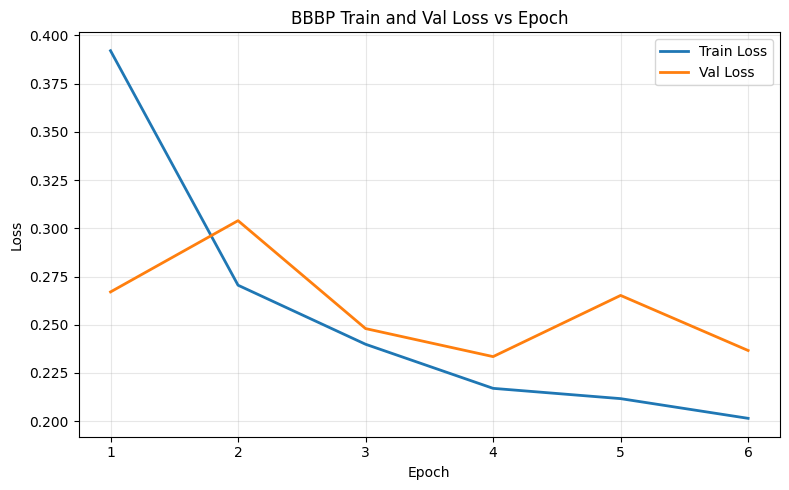

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 7/100, Epoch Accuracy: 92.4060
Saved model with accuracy train model with accuracy92.41% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_92.406.pth
Train AUC-ROC: 0.9749, Train F1 Score: 0.9232 , Train Precision: 0.9419, Train Recall: 0.9052

Epoch Val Accuracy : 90.1667
Val AUC-ROC: 0.9734, Val F1 Score: 0.8952, Val Precision: 0.9655, Val Recall: 0.8344



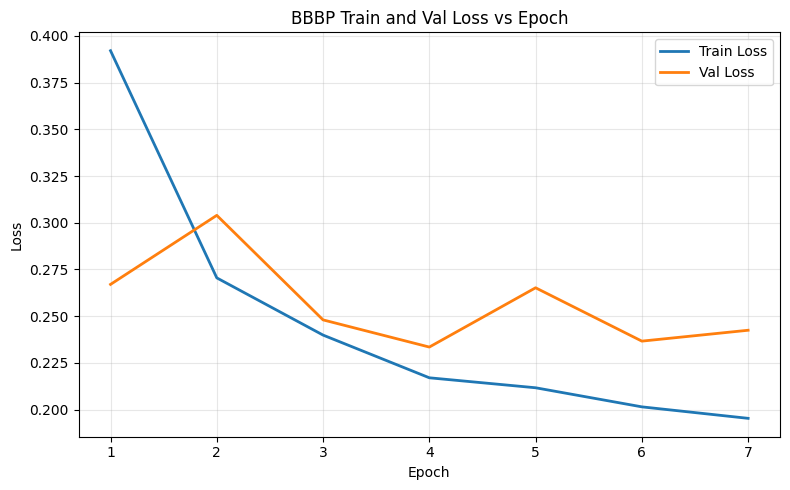

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 8/100, Epoch Accuracy: 92.9802
Saved model with accuracy train model with accuracy92.98% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_92.980.pth
Train AUC-ROC: 0.9768, Train F1 Score: 0.9288 , Train Precision: 0.9500, Train Recall: 0.9085

Epoch Val Accuracy : 89.8333
Val AUC-ROC: 0.9709, Val F1 Score: 0.8920, Val Precision: 0.9582, Val Recall: 0.8344



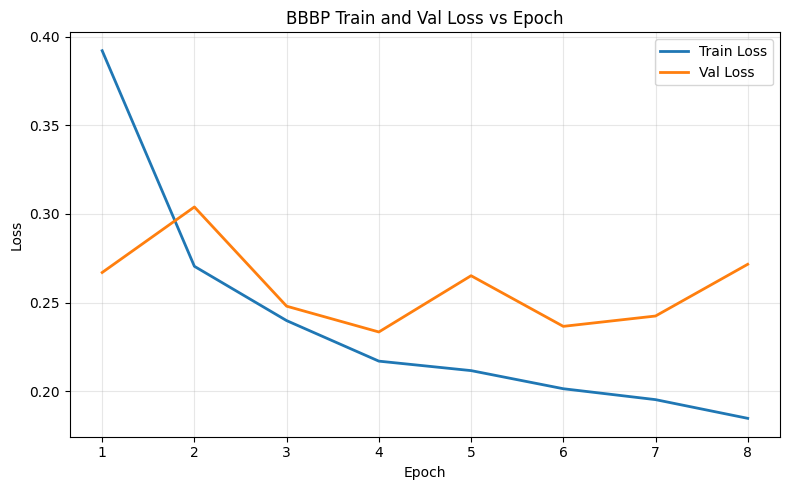

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 9/100, Epoch Accuracy: 92.9061
Train AUC-ROC: 0.9775, Train F1 Score: 0.9284 , Train Precision: 0.9445, Train Recall: 0.9129

Epoch Val Accuracy : 90.3333
Val AUC-ROC: 0.9758, Val F1 Score: 0.8979, Val Precision: 0.9586, Val Recall: 0.8444

Saved best validation model from epoch 9 with validation accuracy 90.33% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_9_acc_90.333.pth


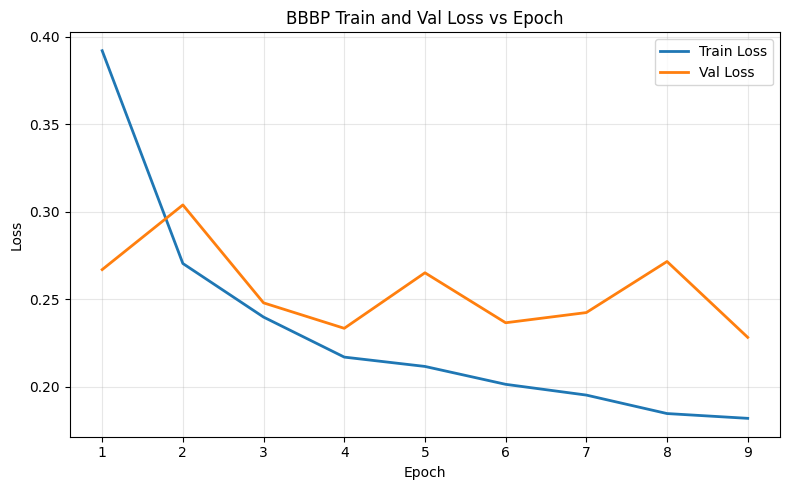

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 10/100, Epoch Accuracy: 93.7211
Saved model with accuracy train model with accuracy93.72% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_93.721.pth
Train AUC-ROC: 0.9795, Train F1 Score: 0.9367 , Train Precision: 0.9522, Train Recall: 0.9217

Epoch Val Accuracy : 89.3333
Val AUC-ROC: 0.9765, Val F1 Score: 0.8853, Val Precision: 0.9648, Val Recall: 0.8179



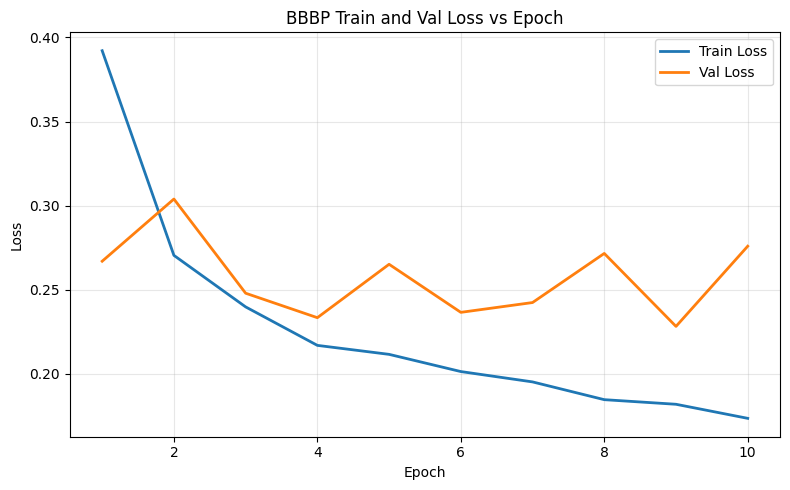

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 11/100, Epoch Accuracy: 93.3877
Train AUC-ROC: 0.9808, Train F1 Score: 0.9333 , Train Precision: 0.9494, Train Recall: 0.9177

Epoch Val Accuracy : 91.0000
Val AUC-ROC: 0.9770, Val F1 Score: 0.9078, Val Precision: 0.9366, Val Recall: 0.8808

Saved best validation model from epoch 11 with validation accuracy 91.00% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_11_acc_91.000.pth


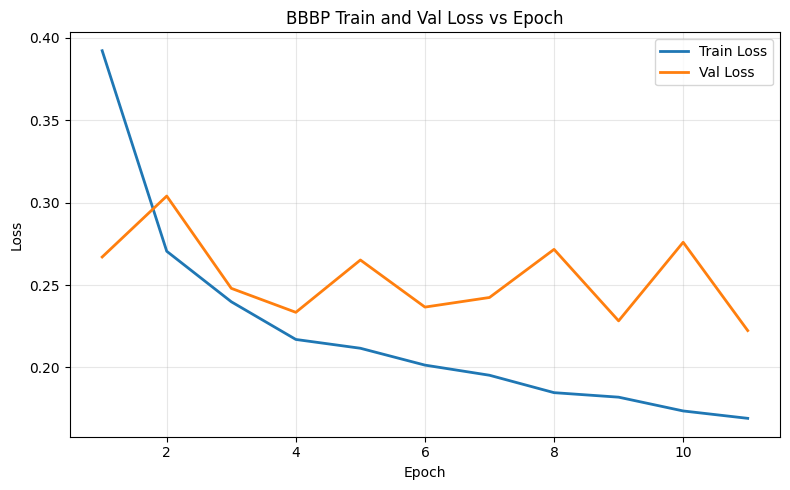

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 12/100, Epoch Accuracy: 93.5358
Train AUC-ROC: 0.9800, Train F1 Score: 0.9347 , Train Precision: 0.9523, Train Recall: 0.9177

Epoch Val Accuracy : 90.6667
Val AUC-ROC: 0.9756, Val F1 Score: 0.9021, Val Precision: 0.9556, Val Recall: 0.8543



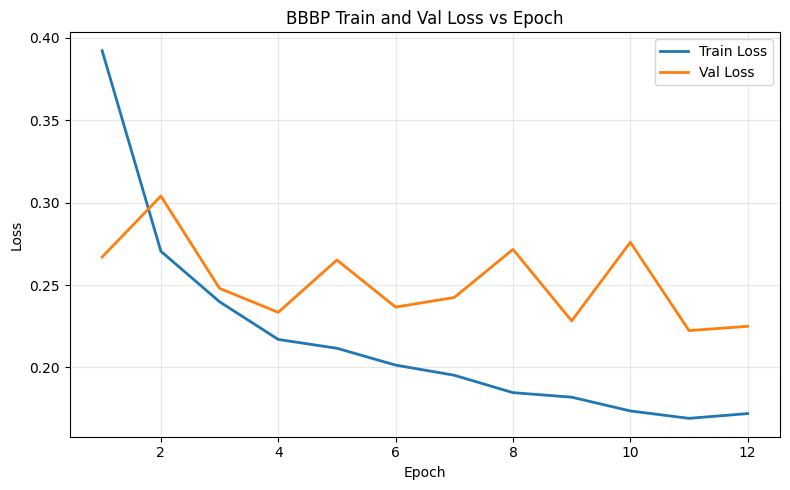

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 13/100, Epoch Accuracy: 94.1471
Saved model with accuracy train model with accuracy94.15% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_94.147.pth
Train AUC-ROC: 0.9826, Train F1 Score: 0.9410 , Train Precision: 0.9564, Train Recall: 0.9261

Epoch Val Accuracy : 90.8333
Val AUC-ROC: 0.9755, Val F1 Score: 0.9047, Val Precision: 0.9491, Val Recall: 0.8642



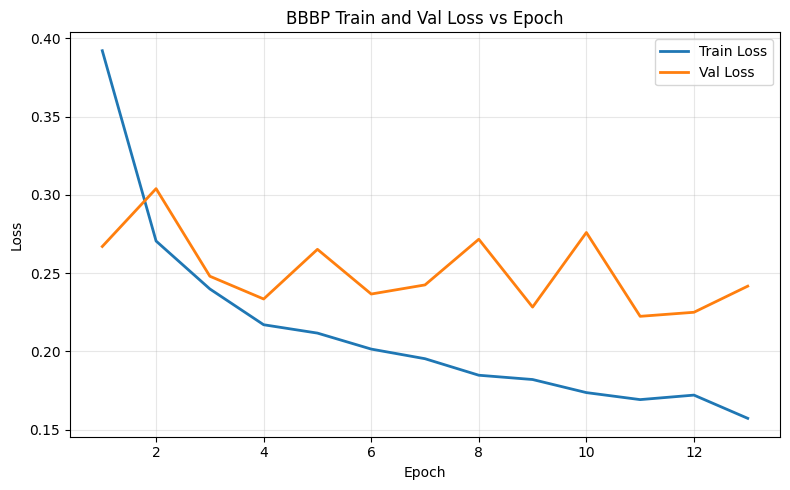

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 14/100, Epoch Accuracy: 94.1100
Train AUC-ROC: 0.9830, Train F1 Score: 0.9407 , Train Precision: 0.9546, Train Recall: 0.9272

Epoch Val Accuracy : 91.1667
Val AUC-ROC: 0.9769, Val F1 Score: 0.9075, Val Precision: 0.9594, Val Recall: 0.8609

Saved best validation model from epoch 14 with validation accuracy 91.17% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_14_acc_91.167.pth


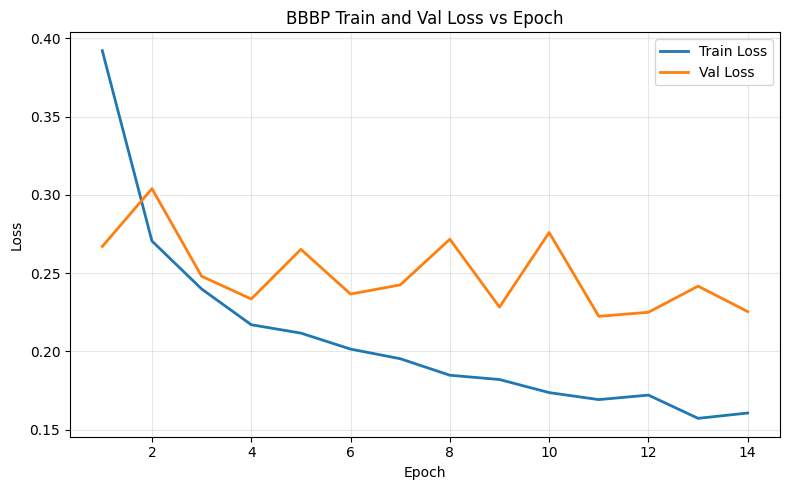

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 15/100, Epoch Accuracy: 94.2952
Saved model with accuracy train model with accuracy94.30% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_94.295.pth
Train AUC-ROC: 0.9836, Train F1 Score: 0.9425 , Train Precision: 0.9575, Train Recall: 0.9280

Epoch Val Accuracy : 91.0000
Val AUC-ROC: 0.9753, Val F1 Score: 0.9097, Val Precision: 0.9189, Val Recall: 0.9007



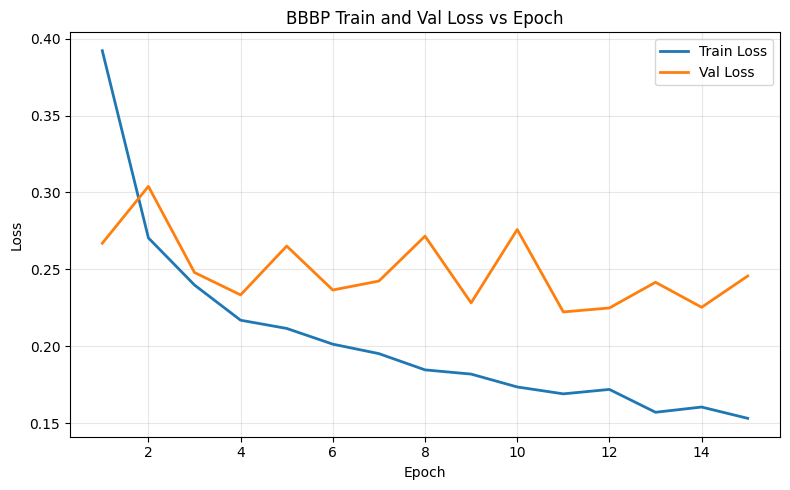

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 16/100, Epoch Accuracy: 94.1285
Train AUC-ROC: 0.9840, Train F1 Score: 0.9411 , Train Precision: 0.9522, Train Recall: 0.9302

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9774, Val F1 Score: 0.9213, Val Precision: 0.9322, Val Recall: 0.9106

Saved best validation model from epoch 16 with validation accuracy 92.17% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_16_acc_92.167.pth


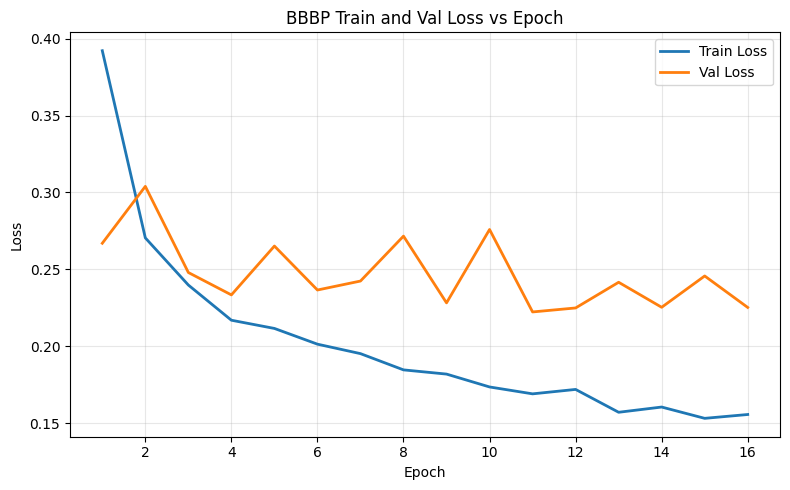

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 17/100, Epoch Accuracy: 94.2397
Train AUC-ROC: 0.9842, Train F1 Score: 0.9421 , Train Precision: 0.9544, Train Recall: 0.9302

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9779, Val F1 Score: 0.9147, Val Precision: 0.9437, Val Recall: 0.8874



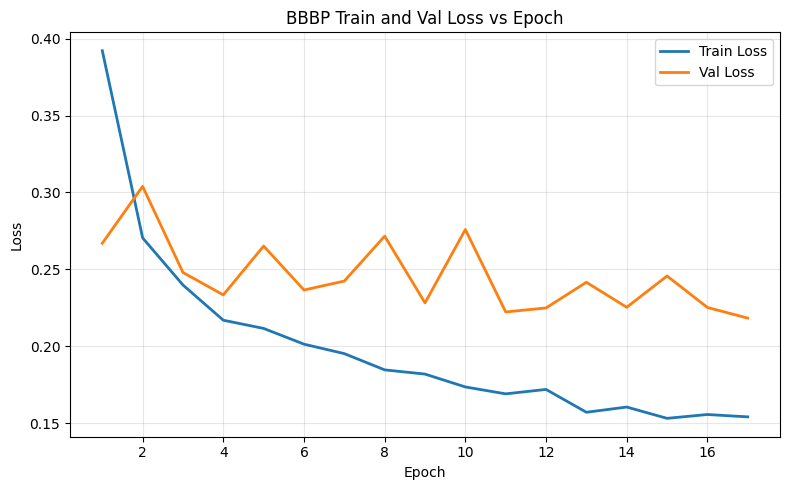

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 18/100, Epoch Accuracy: 94.0915
Train AUC-ROC: 0.9832, Train F1 Score: 0.9404 , Train Precision: 0.9570, Train Recall: 0.9243

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9804, Val F1 Score: 0.9223, Val Precision: 0.9208, Val Recall: 0.9238

Saved best validation model from epoch 18 with validation accuracy 92.17% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_18_acc_92.167.pth


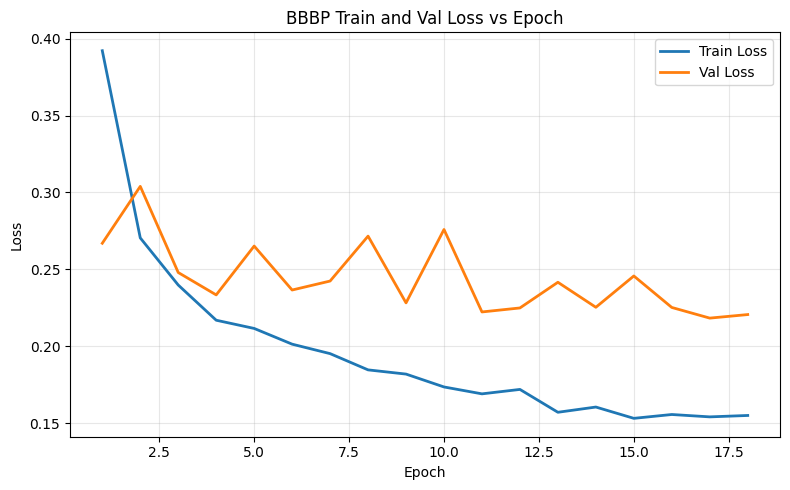

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 19/100, Epoch Accuracy: 94.5916
Saved model with accuracy train model with accuracy94.59% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_94.592.pth
Train AUC-ROC: 0.9853, Train F1 Score: 0.9455 , Train Precision: 0.9606, Train Recall: 0.9309

Epoch Val Accuracy : 91.8333
Val AUC-ROC: 0.9791, Val F1 Score: 0.9198, Val Precision: 0.9094, Val Recall: 0.9305



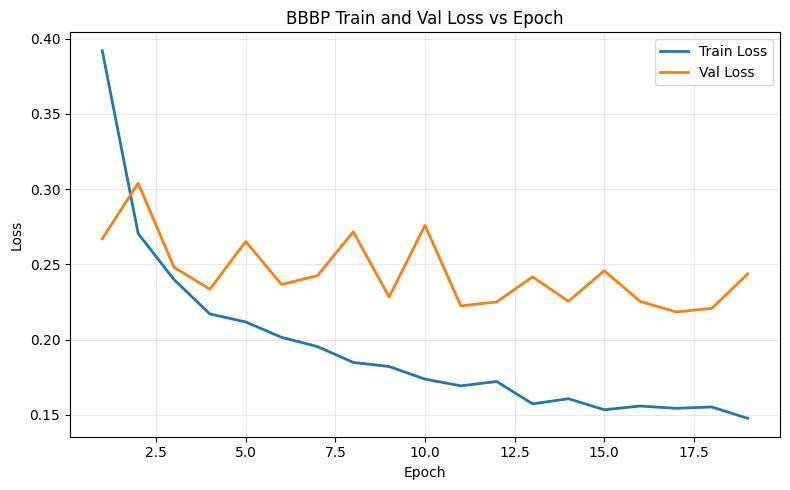

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 20/100, Epoch Accuracy: 94.7583
Saved model with accuracy train model with accuracy94.76% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_94.758.pth
Train AUC-ROC: 0.9850, Train F1 Score: 0.9472 , Train Precision: 0.9617, Train Recall: 0.9331

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9793, Val F1 Score: 0.9189, Val Precision: 0.9379, Val Recall: 0.9007



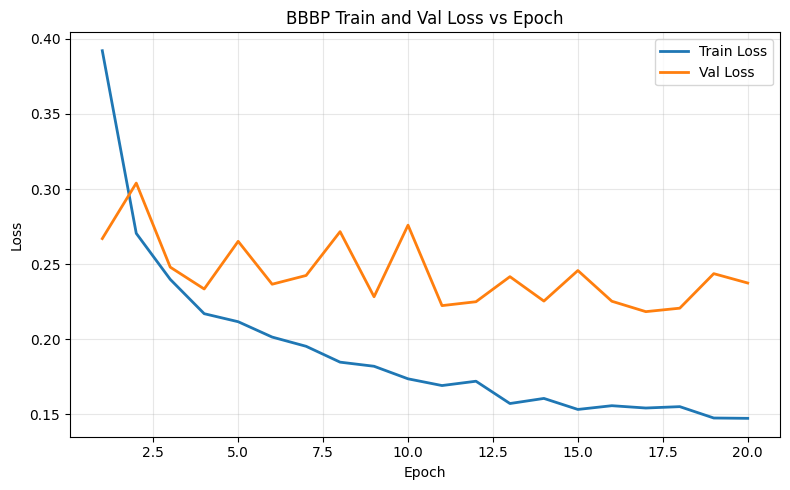

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 21/100, Epoch Accuracy: 94.4249
Train AUC-ROC: 0.9843, Train F1 Score: 0.9439 , Train Precision: 0.9580, Train Recall: 0.9302

Epoch Val Accuracy : 91.3333
Val AUC-ROC: 0.9786, Val F1 Score: 0.9091, Val Precision: 0.9630, Val Recall: 0.8609



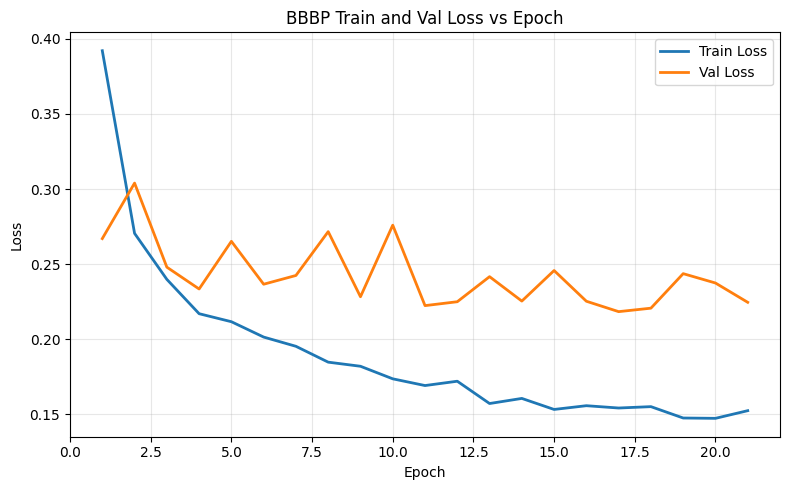

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 22/100, Epoch Accuracy: 94.7583
Saved model with accuracy train model with accuracy94.76% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_94.758.pth
Train AUC-ROC: 0.9857, Train F1 Score: 0.9474 , Train Precision: 0.9583, Train Recall: 0.9368

Epoch Val Accuracy : 92.3333
Val AUC-ROC: 0.9812, Val F1 Score: 0.9231, Val Precision: 0.9324, Val Recall: 0.9139

Saved best validation model from epoch 22 with validation accuracy 92.33% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_22_acc_92.333.pth


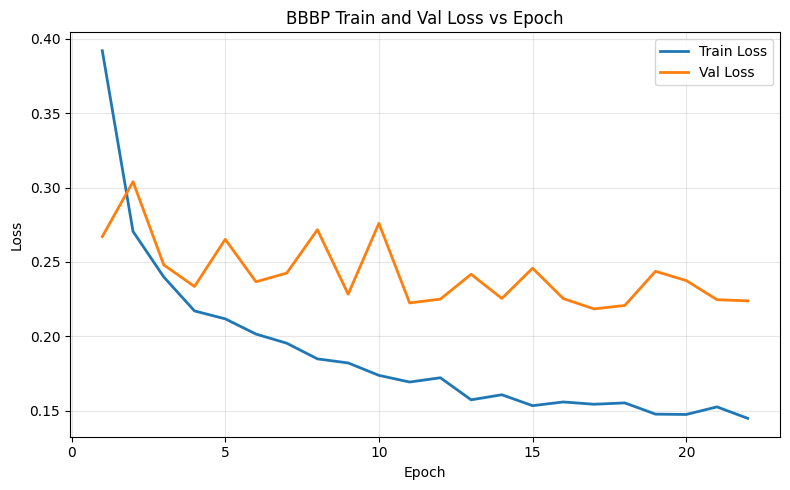

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 23/100, Epoch Accuracy: 94.7583
Saved model with accuracy train model with accuracy94.76% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_94.758.pth
Train AUC-ROC: 0.9872, Train F1 Score: 0.9470 , Train Precision: 0.9649, Train Recall: 0.9298

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9785, Val F1 Score: 0.9215, Val Precision: 0.9293, Val Recall: 0.9139



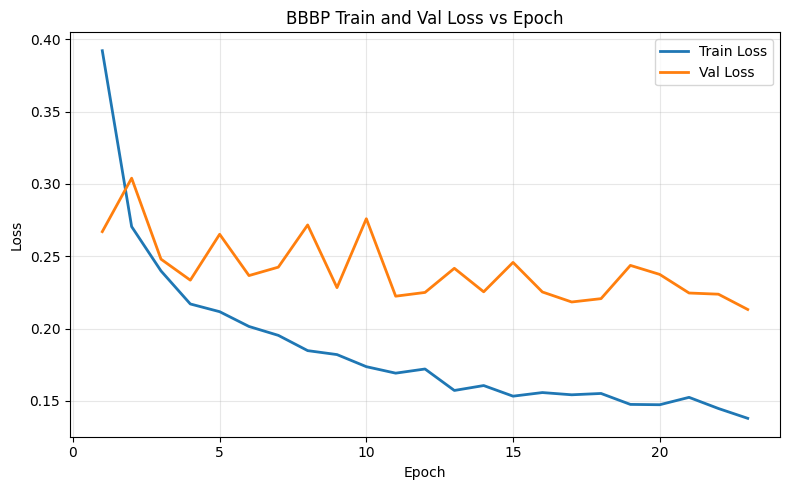

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 24/100, Epoch Accuracy: 94.6101
Train AUC-ROC: 0.9862, Train F1 Score: 0.9458 , Train Precision: 0.9592, Train Recall: 0.9327

Epoch Val Accuracy : 92.5000
Val AUC-ROC: 0.9806, Val F1 Score: 0.9264, Val Precision: 0.9159, Val Recall: 0.9371

Saved best validation model from epoch 24 with validation accuracy 92.50% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_24_acc_92.500.pth


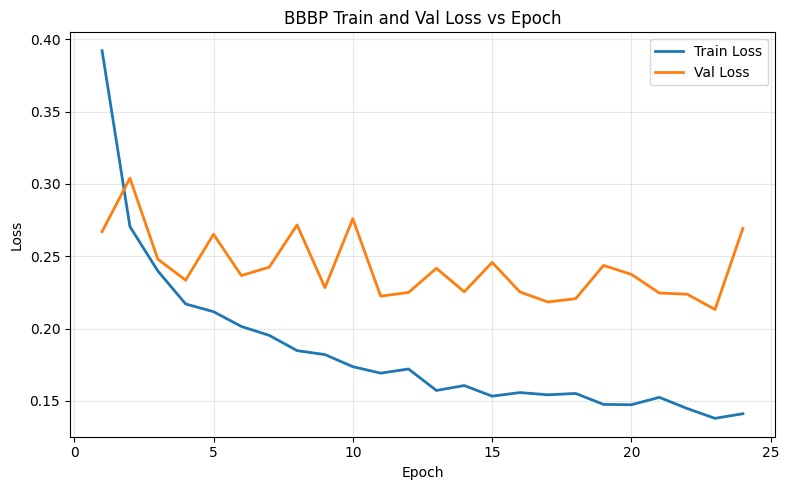

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 25/100, Epoch Accuracy: 94.4619
Train AUC-ROC: 0.9857, Train F1 Score: 0.9442 , Train Precision: 0.9587, Train Recall: 0.9302

Epoch Val Accuracy : 91.3333
Val AUC-ROC: 0.9788, Val F1 Score: 0.9119, Val Precision: 0.9340, Val Recall: 0.8907



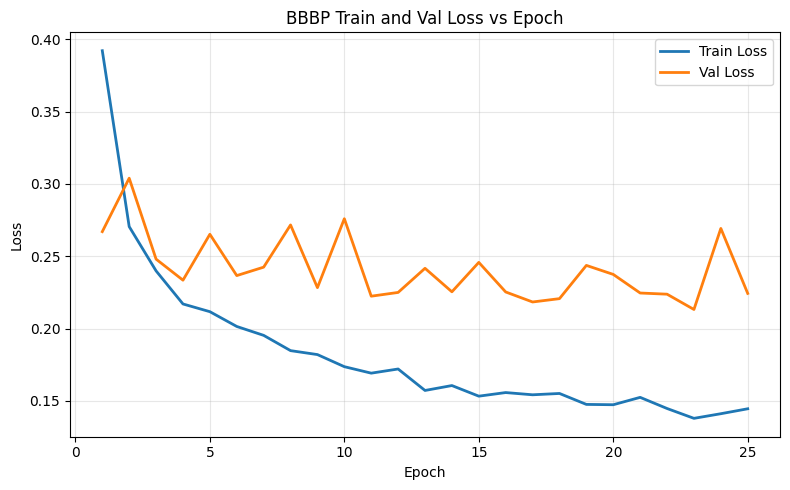

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 26/100, Epoch Accuracy: 94.7583
Saved model with accuracy train model with accuracy94.76% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_94.758.pth
Train AUC-ROC: 0.9869, Train F1 Score: 0.9474 , Train Precision: 0.9583, Train Recall: 0.9368

Epoch Val Accuracy : 91.3333
Val AUC-ROC: 0.9811, Val F1 Score: 0.9145, Val Precision: 0.9085, Val Recall: 0.9205



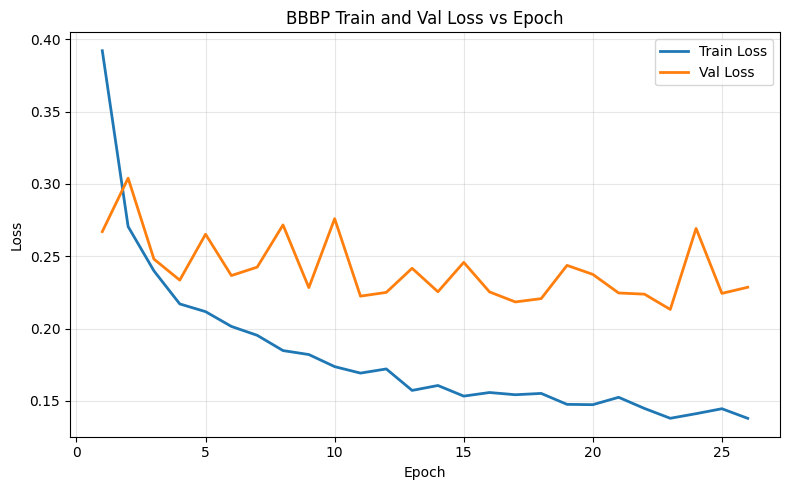

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 27/100, Epoch Accuracy: 94.8324
Saved model with accuracy train model with accuracy94.83% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_94.832.pth
Train AUC-ROC: 0.9867, Train F1 Score: 0.9481 , Train Precision: 0.9597, Train Recall: 0.9368

Epoch Val Accuracy : 91.3333
Val AUC-ROC: 0.9795, Val F1 Score: 0.9153, Val Precision: 0.9006, Val Recall: 0.9305



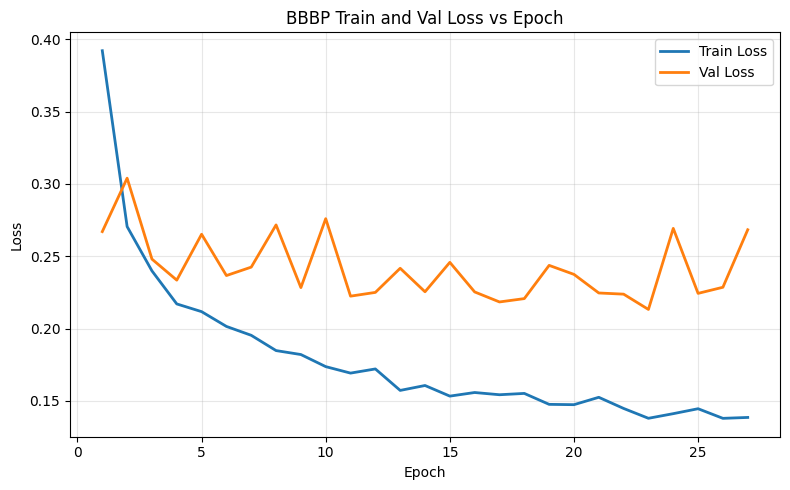

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 28/100, Epoch Accuracy: 95.0917
Saved model with accuracy train model with accuracy95.09% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.092.pth
Train AUC-ROC: 0.9874, Train F1 Score: 0.9507 , Train Precision: 0.9634, Train Recall: 0.9383

Epoch Val Accuracy : 91.0000
Val AUC-ROC: 0.9793, Val F1 Score: 0.9106, Val Precision: 0.9106, Val Recall: 0.9106



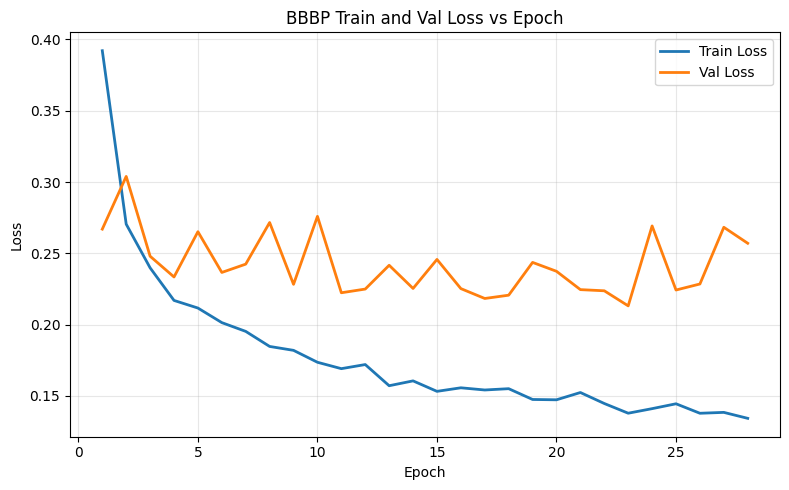

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 29/100, Epoch Accuracy: 95.1658
Saved model with accuracy train model with accuracy95.17% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.166.pth
Train AUC-ROC: 0.9877, Train F1 Score: 0.9513 , Train Precision: 0.9670, Train Recall: 0.9361

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9776, Val F1 Score: 0.9203, Val Precision: 0.9233, Val Recall: 0.9172



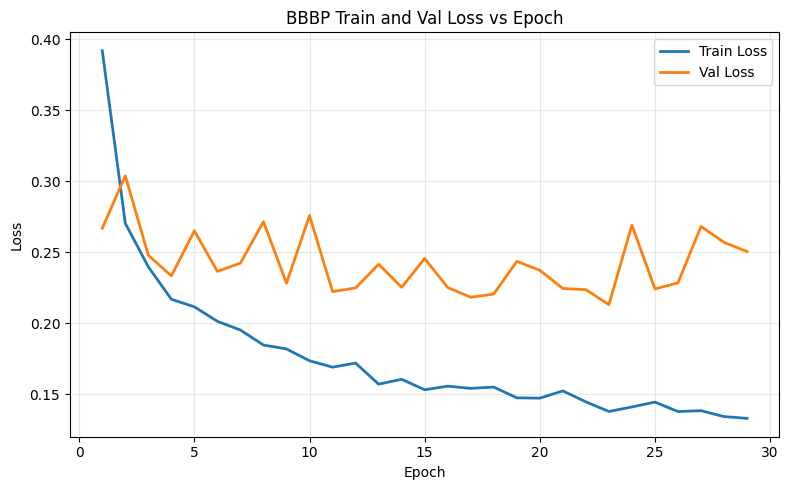

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 30/100, Epoch Accuracy: 95.2769
Saved model with accuracy train model with accuracy95.28% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.277.pth
Train AUC-ROC: 0.9883, Train F1 Score: 0.9525 , Train Precision: 0.9653, Train Recall: 0.9401

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9787, Val F1 Score: 0.9150, Val Precision: 0.9406, Val Recall: 0.8907



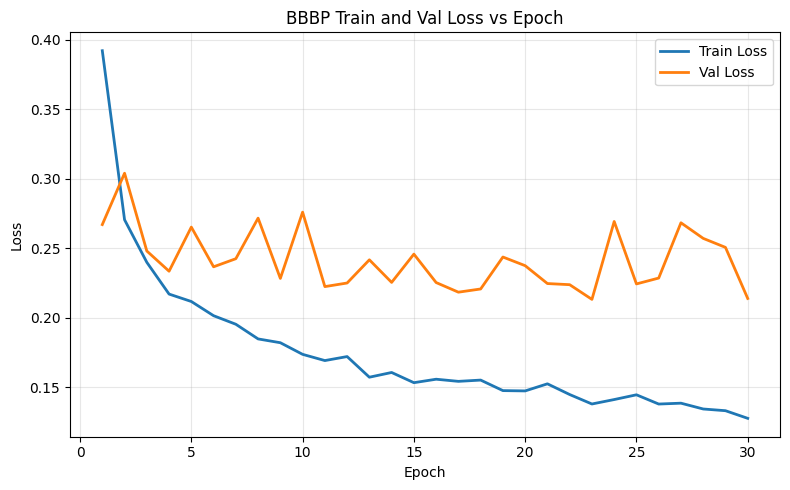

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 31/100, Epoch Accuracy: 95.5918
Saved model with accuracy train model with accuracy95.59% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.592.pth
Train AUC-ROC: 0.9887, Train F1 Score: 0.9557 , Train Precision: 0.9673, Train Recall: 0.9445

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9795, Val F1 Score: 0.9233, Val Precision: 0.9100, Val Recall: 0.9371



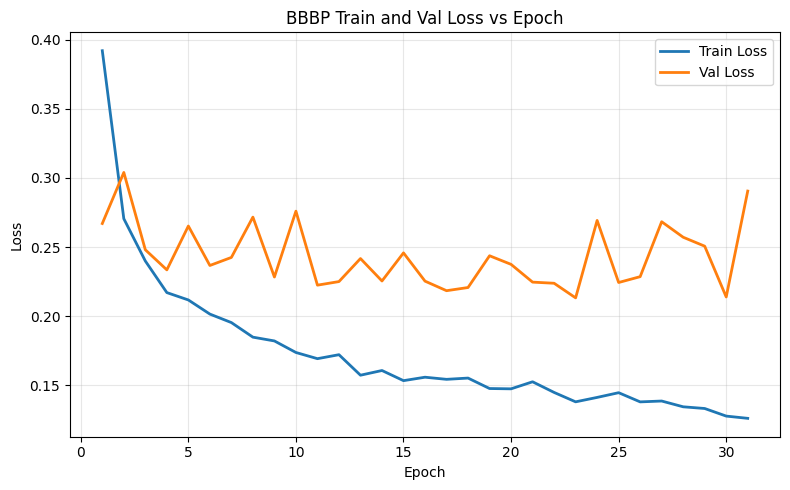

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 32/100, Epoch Accuracy: 95.2584
Train AUC-ROC: 0.9878, Train F1 Score: 0.9523 , Train Precision: 0.9656, Train Recall: 0.9394

Epoch Val Accuracy : 91.5000
Val AUC-ROC: 0.9784, Val F1 Score: 0.9151, Val Precision: 0.9197, Val Recall: 0.9106



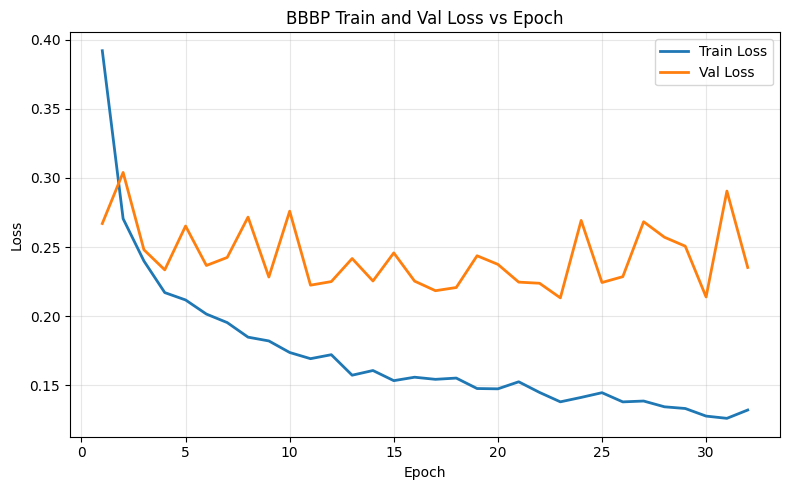

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 33/100, Epoch Accuracy: 94.9991
Train AUC-ROC: 0.9874, Train F1 Score: 0.9498 , Train Precision: 0.9605, Train Recall: 0.9394

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9777, Val F1 Score: 0.9167, Val Precision: 0.9228, Val Recall: 0.9106



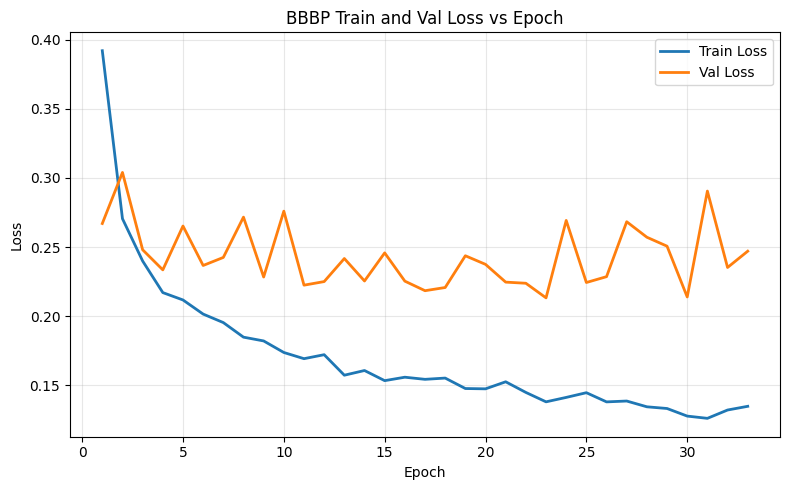

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 34/100, Epoch Accuracy: 95.3139
Train AUC-ROC: 0.9875, Train F1 Score: 0.9529 , Train Precision: 0.9660, Train Recall: 0.9401

Epoch Val Accuracy : 90.8333
Val AUC-ROC: 0.9765, Val F1 Score: 0.9060, Val Precision: 0.9364, Val Recall: 0.8775



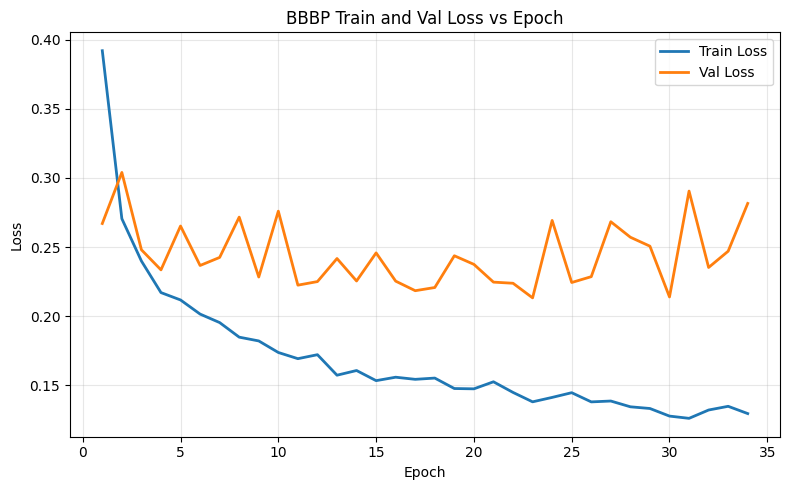

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 35/100, Epoch Accuracy: 95.1843
Train AUC-ROC: 0.9877, Train F1 Score: 0.9517 , Train Precision: 0.9628, Train Recall: 0.9408

Epoch Val Accuracy : 90.8333
Val AUC-ROC: 0.9773, Val F1 Score: 0.9097, Val Precision: 0.9023, Val Recall: 0.9172



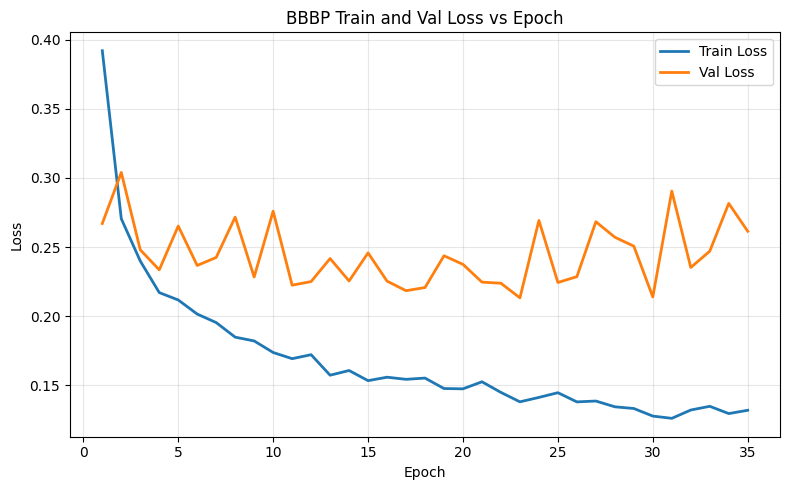

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 36/100, Epoch Accuracy: 95.2954
Train AUC-ROC: 0.9893, Train F1 Score: 0.9528 , Train Precision: 0.9642, Train Recall: 0.9416

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9767, Val F1 Score: 0.9200, Val Precision: 0.9262, Val Recall: 0.9139



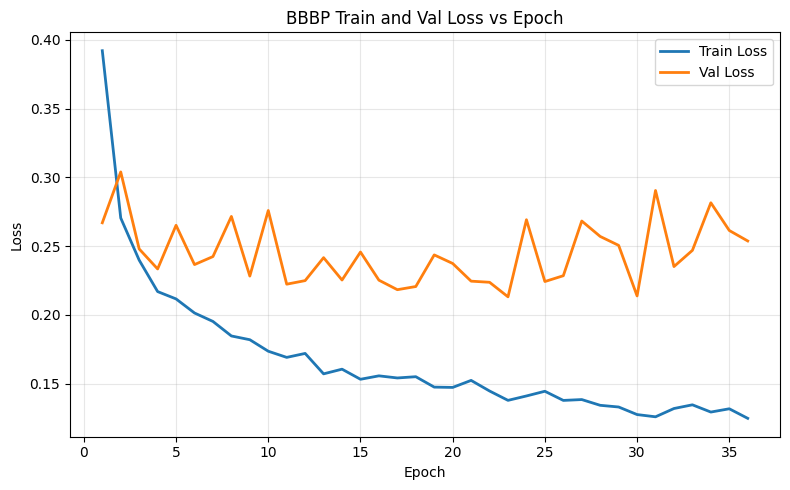

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 37/100, Epoch Accuracy: 95.1843
Train AUC-ROC: 0.9886, Train F1 Score: 0.9518 , Train Precision: 0.9603, Train Recall: 0.9434

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9788, Val F1 Score: 0.9208, Val Precision: 0.9178, Val Recall: 0.9238



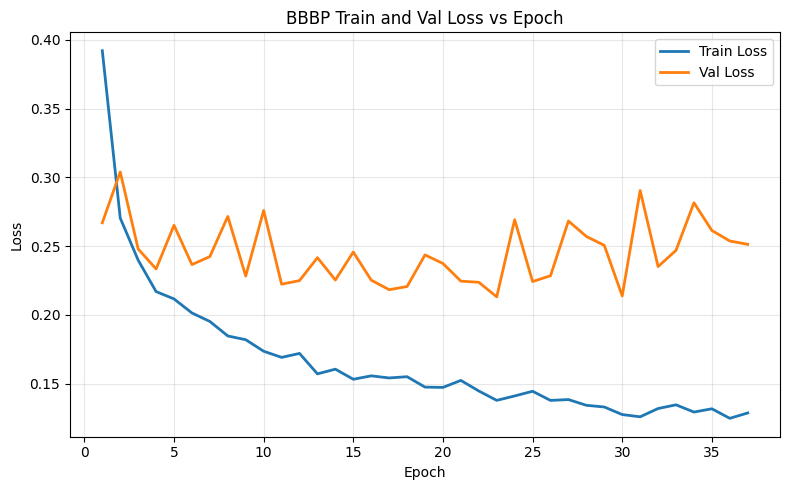

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 38/100, Epoch Accuracy: 95.8140
Saved model with accuracy train model with accuracy95.81% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.814.pth
Train AUC-ROC: 0.9888, Train F1 Score: 0.9581 , Train Precision: 0.9678, Train Recall: 0.9485

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9795, Val F1 Score: 0.9199, Val Precision: 0.9474, Val Recall: 0.8940



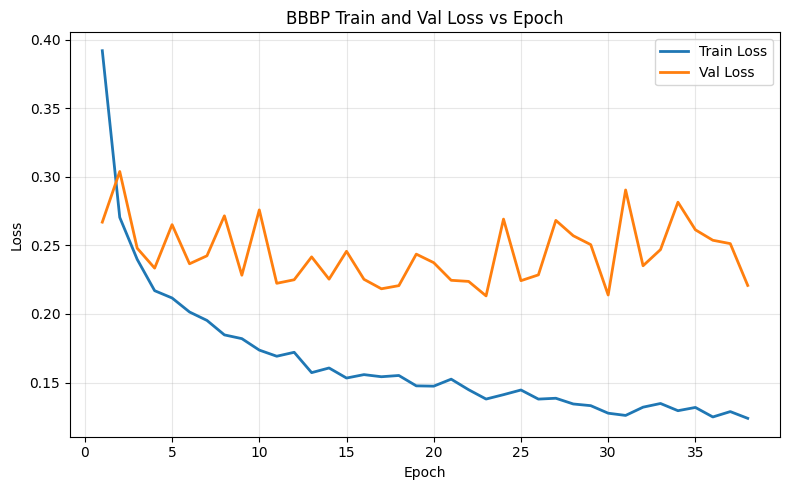

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 39/100, Epoch Accuracy: 95.4066
Train AUC-ROC: 0.9887, Train F1 Score: 0.9540 , Train Precision: 0.9633, Train Recall: 0.9449

Epoch Val Accuracy : 91.5000
Val AUC-ROC: 0.9789, Val F1 Score: 0.9151, Val Precision: 0.9197, Val Recall: 0.9106



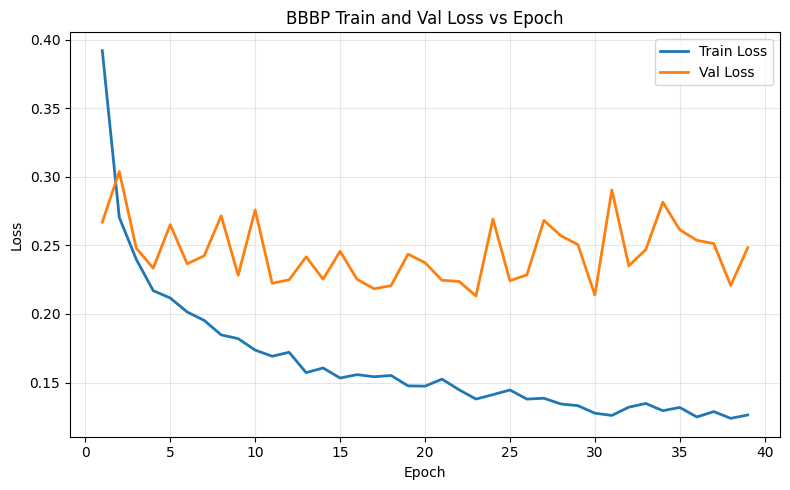

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 40/100, Epoch Accuracy: 95.4992
Train AUC-ROC: 0.9893, Train F1 Score: 0.9549 , Train Precision: 0.9647, Train Recall: 0.9452

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9779, Val F1 Score: 0.9211, Val Precision: 0.9150, Val Recall: 0.9272



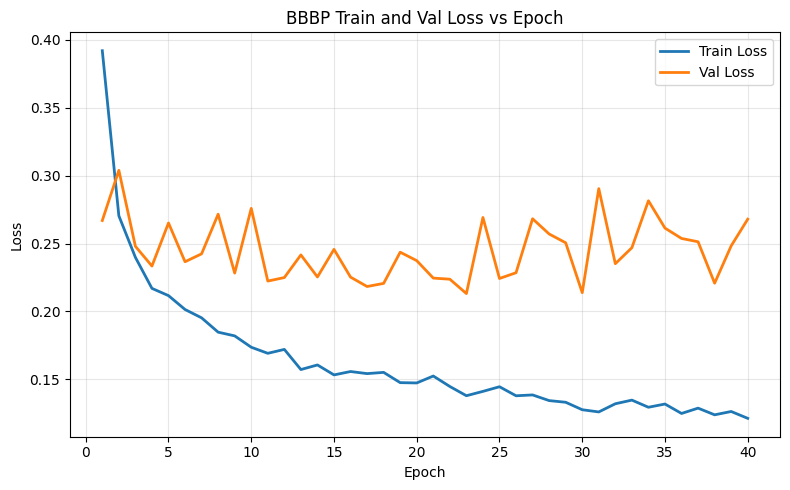

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 41/100, Epoch Accuracy: 95.1472
Train AUC-ROC: 0.9882, Train F1 Score: 0.9512 , Train Precision: 0.9638, Train Recall: 0.9390

Epoch Val Accuracy : 91.3333
Val AUC-ROC: 0.9790, Val F1 Score: 0.9113, Val Precision: 0.9401, Val Recall: 0.8841



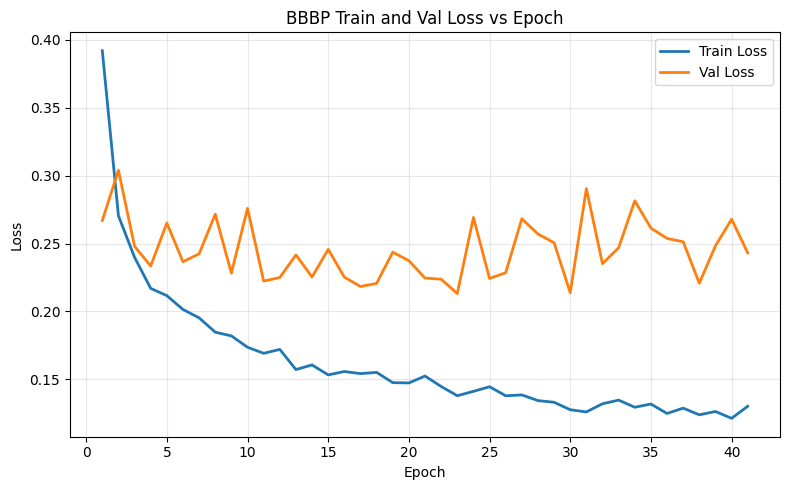

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 42/100, Epoch Accuracy: 95.6659
Train AUC-ROC: 0.9884, Train F1 Score: 0.9565 , Train Precision: 0.9684, Train Recall: 0.9449

Epoch Val Accuracy : 92.5000
Val AUC-ROC: 0.9799, Val F1 Score: 0.9259, Val Precision: 0.9213, Val Recall: 0.9305

Saved best validation model from epoch 42 with validation accuracy 92.50% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_42_acc_92.500.pth


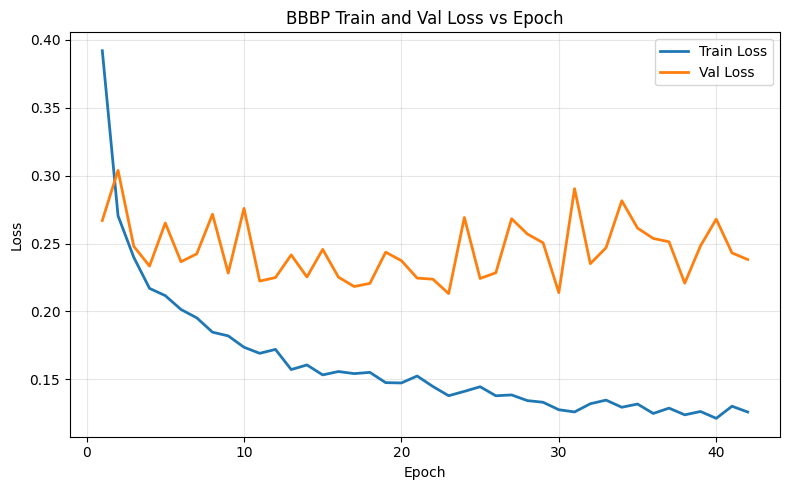

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 43/100, Epoch Accuracy: 95.8140
Saved model with accuracy train model with accuracy95.81% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.814.pth
Train AUC-ROC: 0.9894, Train F1 Score: 0.9580 , Train Precision: 0.9681, Train Recall: 0.9482

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9774, Val F1 Score: 0.9226, Val Precision: 0.9180, Val Recall: 0.9272



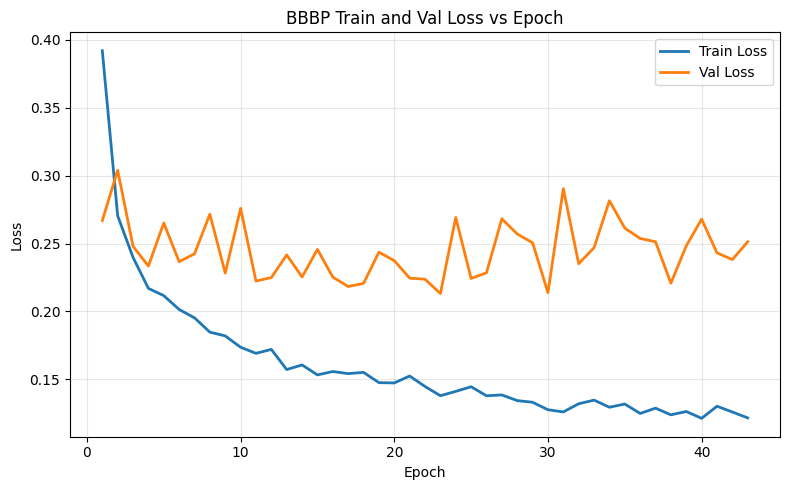

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 44/100, Epoch Accuracy: 95.5547
Train AUC-ROC: 0.9886, Train F1 Score: 0.9554 , Train Precision: 0.9655, Train Recall: 0.9456

Epoch Val Accuracy : 90.8333
Val AUC-ROC: 0.9785, Val F1 Score: 0.9120, Val Precision: 0.8824, Val Recall: 0.9437



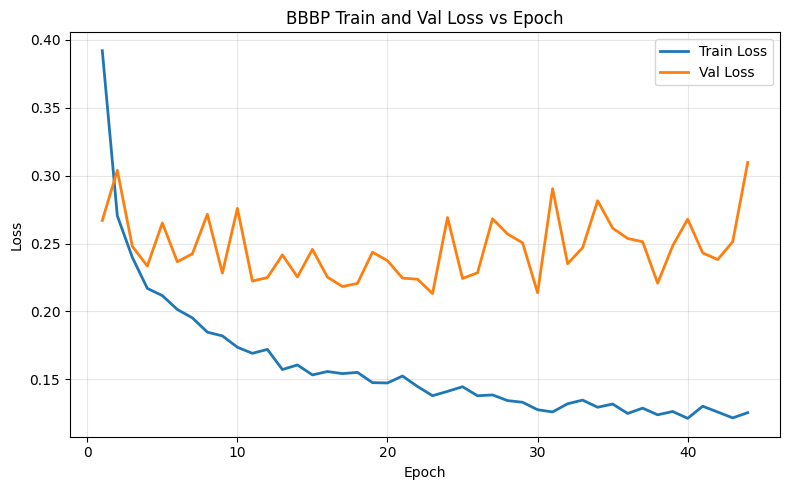

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 45/100, Epoch Accuracy: 95.5362
Train AUC-ROC: 0.9892, Train F1 Score: 0.9552 , Train Precision: 0.9655, Train Recall: 0.9452

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9775, Val F1 Score: 0.9158, Val Precision: 0.9315, Val Recall: 0.9007



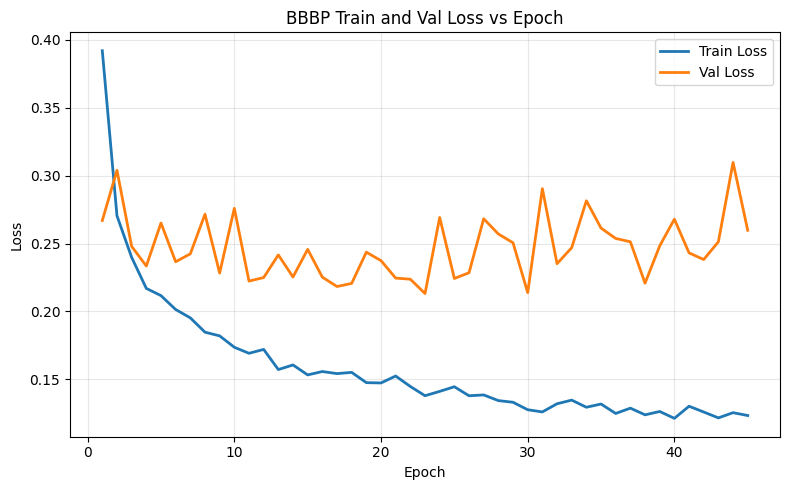

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 46/100, Epoch Accuracy: 95.8511
Saved model with accuracy train model with accuracy95.85% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.851.pth
Train AUC-ROC: 0.9898, Train F1 Score: 0.9585 , Train Precision: 0.9671, Train Recall: 0.9500

Epoch Val Accuracy : 91.0000
Val AUC-ROC: 0.9784, Val F1 Score: 0.9140, Val Precision: 0.8804, Val Recall: 0.9503



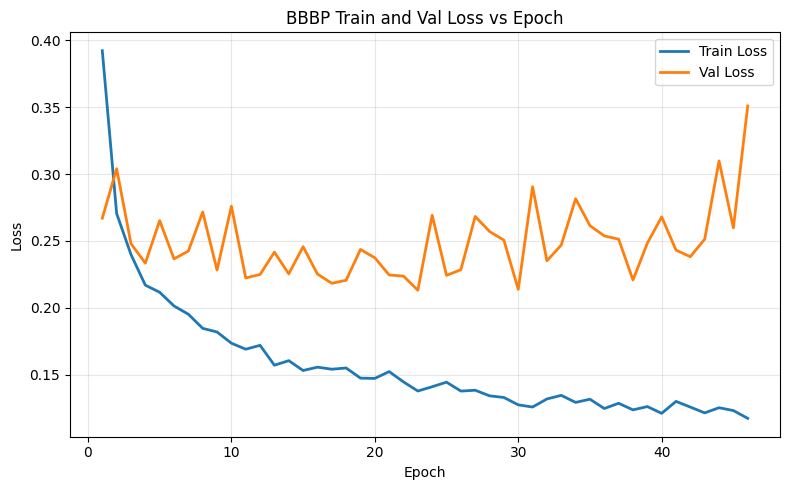

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 47/100, Epoch Accuracy: 95.7955
Train AUC-ROC: 0.9897, Train F1 Score: 0.9577 , Train Precision: 0.9709, Train Recall: 0.9449

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9769, Val F1 Score: 0.9169, Val Precision: 0.9200, Val Recall: 0.9139



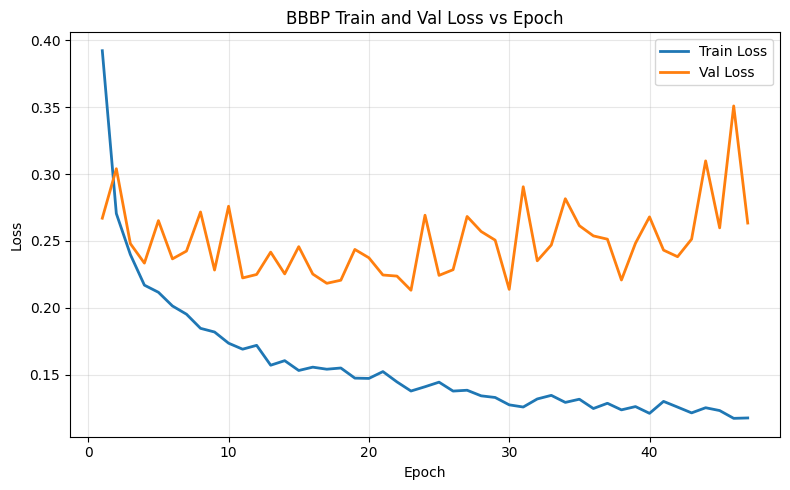

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 48/100, Epoch Accuracy: 95.5918
Train AUC-ROC: 0.9892, Train F1 Score: 0.9558 , Train Precision: 0.9669, Train Recall: 0.9449

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9789, Val F1 Score: 0.9218, Val Precision: 0.9264, Val Recall: 0.9172



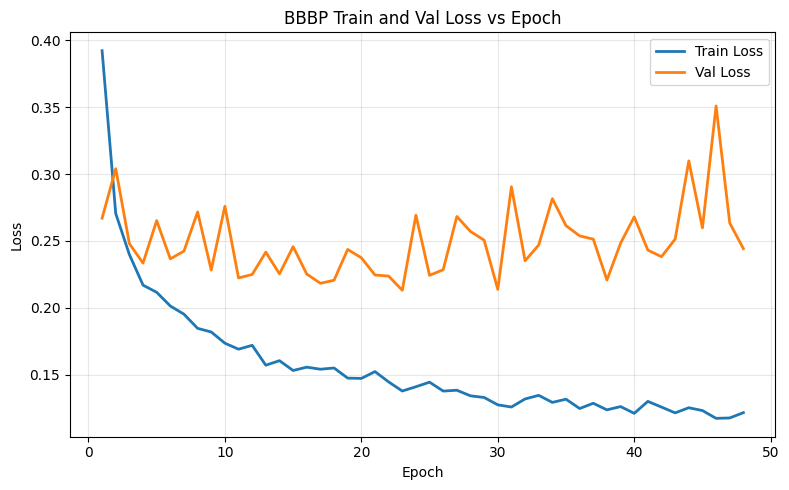

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 49/100, Epoch Accuracy: 95.7029
Train AUC-ROC: 0.9895, Train F1 Score: 0.9569 , Train Precision: 0.9677, Train Recall: 0.9463

Epoch Val Accuracy : 91.1667
Val AUC-ROC: 0.9782, Val F1 Score: 0.9144, Val Precision: 0.8927, Val Recall: 0.9371



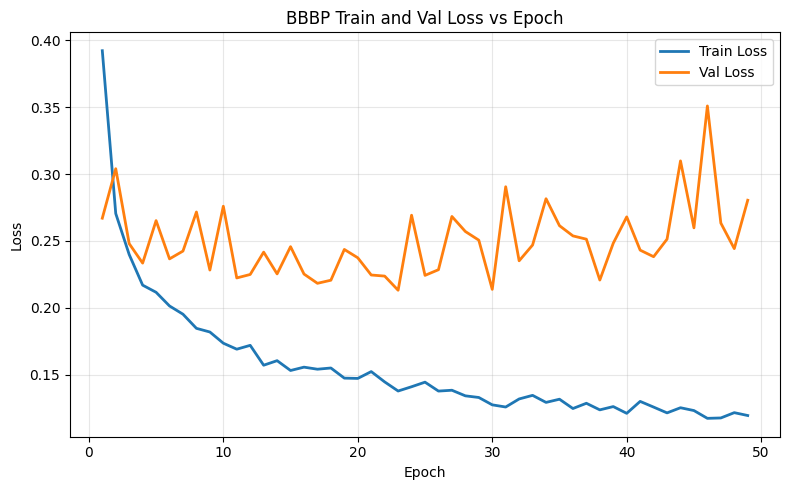

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 50/100, Epoch Accuracy: 95.8511
Saved model with accuracy train model with accuracy95.85% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.851.pth
Train AUC-ROC: 0.9907, Train F1 Score: 0.9584 , Train Precision: 0.9681, Train Recall: 0.9489

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9805, Val F1 Score: 0.9180, Val Precision: 0.9091, Val Recall: 0.9272



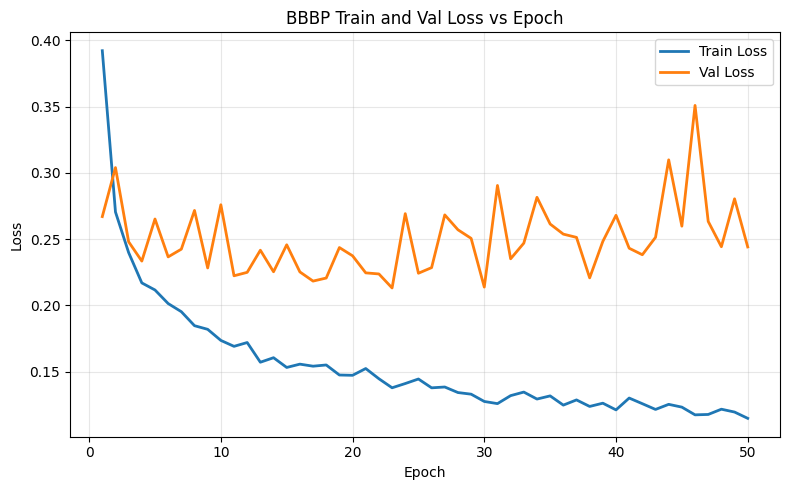

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 51/100, Epoch Accuracy: 95.5733
Train AUC-ROC: 0.9896, Train F1 Score: 0.9556 , Train Precision: 0.9672, Train Recall: 0.9441

Epoch Val Accuracy : 91.5000
Val AUC-ROC: 0.9790, Val F1 Score: 0.9134, Val Precision: 0.9373, Val Recall: 0.8907



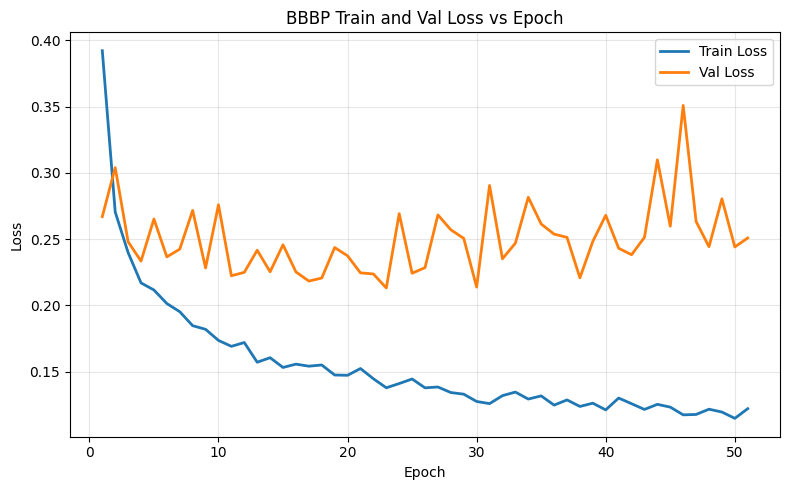

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 52/100, Epoch Accuracy: 95.9993
Saved model with accuracy train model with accuracy96.00% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_95.999.pth
Train AUC-ROC: 0.9909, Train F1 Score: 0.9599 , Train Precision: 0.9689, Train Recall: 0.9511

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9810, Val F1 Score: 0.9205, Val Precision: 0.9205, Val Recall: 0.9205



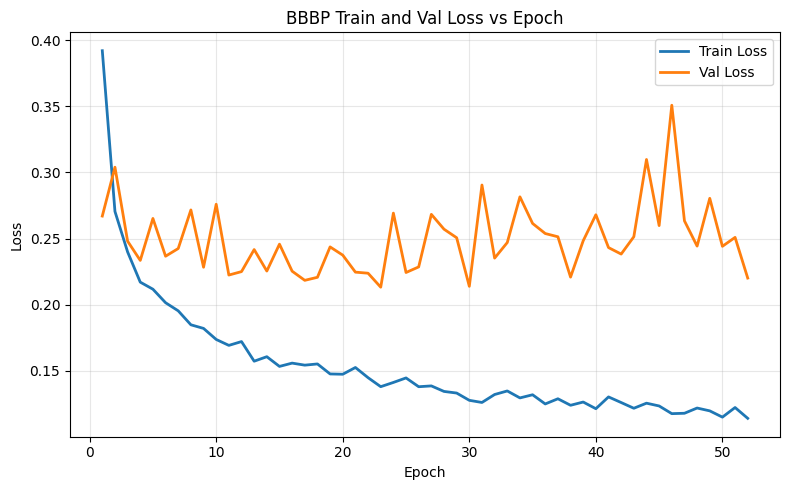

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 53/100, Epoch Accuracy: 95.4251
Train AUC-ROC: 0.9894, Train F1 Score: 0.9541 , Train Precision: 0.9650, Train Recall: 0.9434

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9789, Val F1 Score: 0.9208, Val Precision: 0.9178, Val Recall: 0.9238



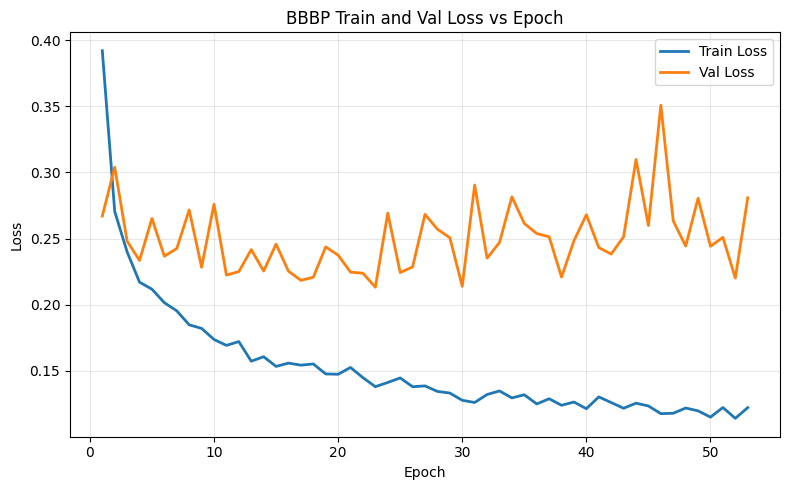

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 54/100, Epoch Accuracy: 96.0178
Saved model with accuracy train model with accuracy96.02% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_96.018.pth
Train AUC-ROC: 0.9901, Train F1 Score: 0.9602 , Train Precision: 0.9682, Train Recall: 0.9522

Epoch Val Accuracy : 90.8333
Val AUC-ROC: 0.9792, Val F1 Score: 0.9053, Val Precision: 0.9427, Val Recall: 0.8709



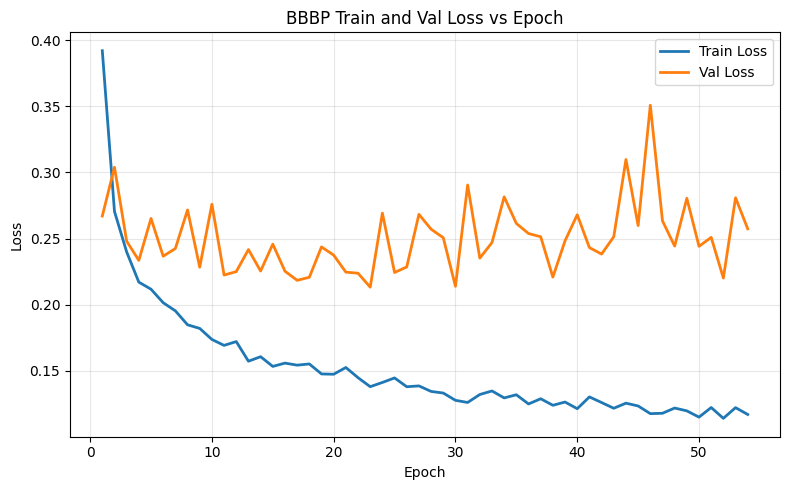

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 55/100, Epoch Accuracy: 96.0178
Saved model with accuracy train model with accuracy96.02% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_96.018.pth
Train AUC-ROC: 0.9902, Train F1 Score: 0.9601 , Train Precision: 0.9707, Train Recall: 0.9497

Epoch Val Accuracy : 91.8333
Val AUC-ROC: 0.9804, Val F1 Score: 0.9195, Val Precision: 0.9121, Val Recall: 0.9272



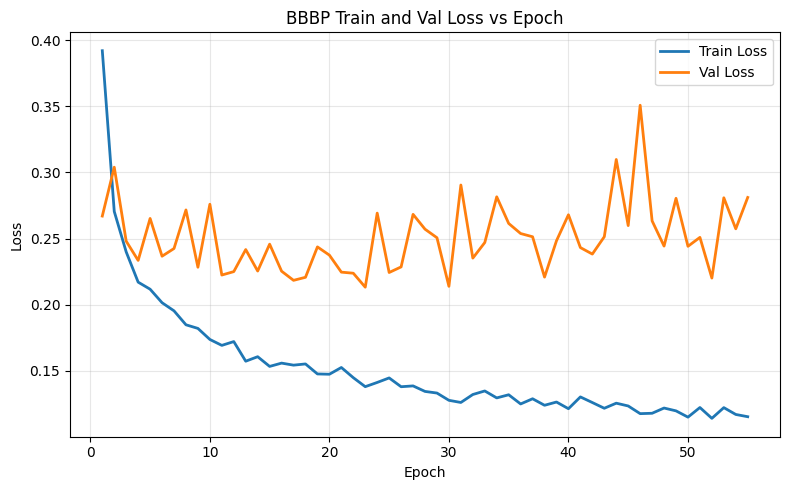

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 56/100, Epoch Accuracy: 95.7400
Train AUC-ROC: 0.9904, Train F1 Score: 0.9572 , Train Precision: 0.9684, Train Recall: 0.9463

Epoch Val Accuracy : 91.5000
Val AUC-ROC: 0.9792, Val F1 Score: 0.9173, Val Precision: 0.8984, Val Recall: 0.9371



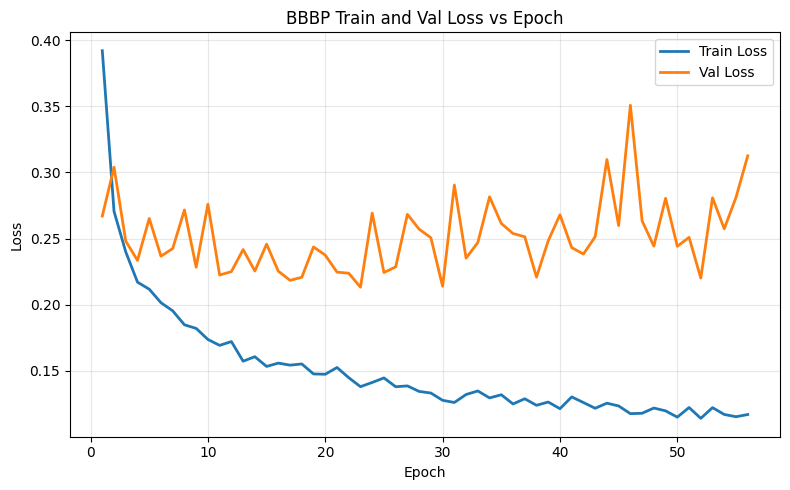

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 57/100, Epoch Accuracy: 96.1289
Saved model with accuracy train model with accuracy96.13% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_96.129.pth
Train AUC-ROC: 0.9904, Train F1 Score: 0.9612 , Train Precision: 0.9711, Train Recall: 0.9515

Epoch Val Accuracy : 91.5000
Val AUC-ROC: 0.9803, Val F1 Score: 0.9171, Val Precision: 0.9010, Val Recall: 0.9338



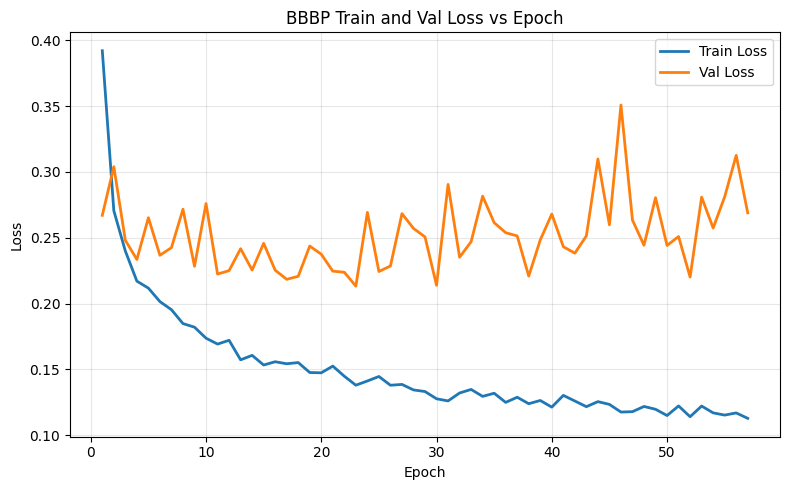

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 58/100, Epoch Accuracy: 95.8511
Train AUC-ROC: 0.9907, Train F1 Score: 0.9584 , Train Precision: 0.9678, Train Recall: 0.9493

Epoch Val Accuracy : 92.3333
Val AUC-ROC: 0.9804, Val F1 Score: 0.9251, Val Precision: 0.9103, Val Recall: 0.9404



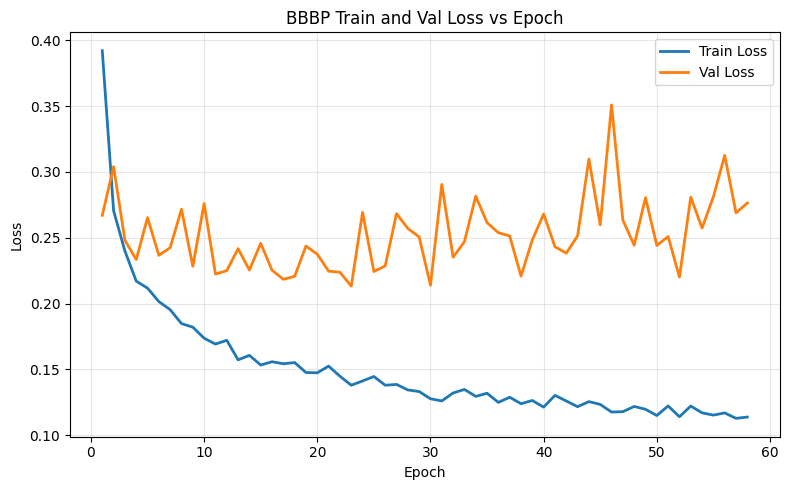

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 59/100, Epoch Accuracy: 96.1104
Train AUC-ROC: 0.9898, Train F1 Score: 0.9610 , Train Precision: 0.9715, Train Recall: 0.9508

Epoch Val Accuracy : 91.3333
Val AUC-ROC: 0.9794, Val F1 Score: 0.9130, Val Precision: 0.9223, Val Recall: 0.9040



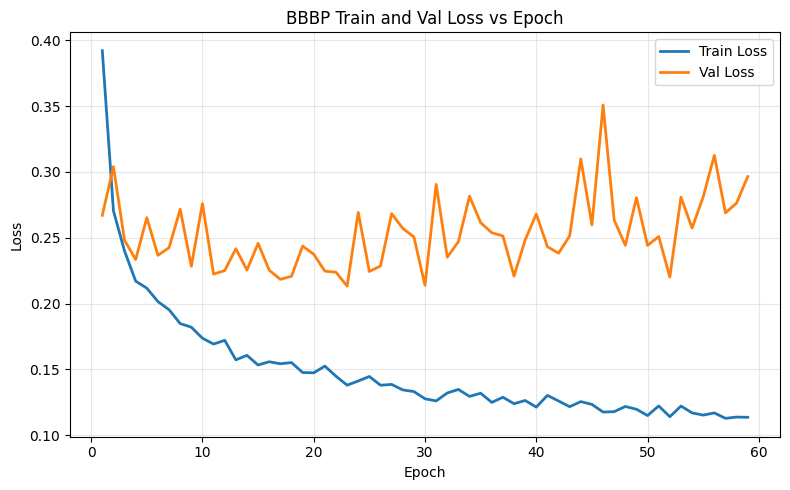

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 60/100, Epoch Accuracy: 95.7585
Train AUC-ROC: 0.9899, Train F1 Score: 0.9575 , Train Precision: 0.9677, Train Recall: 0.9474

Epoch Val Accuracy : 91.0000
Val AUC-ROC: 0.9793, Val F1 Score: 0.9112, Val Precision: 0.9052, Val Recall: 0.9172



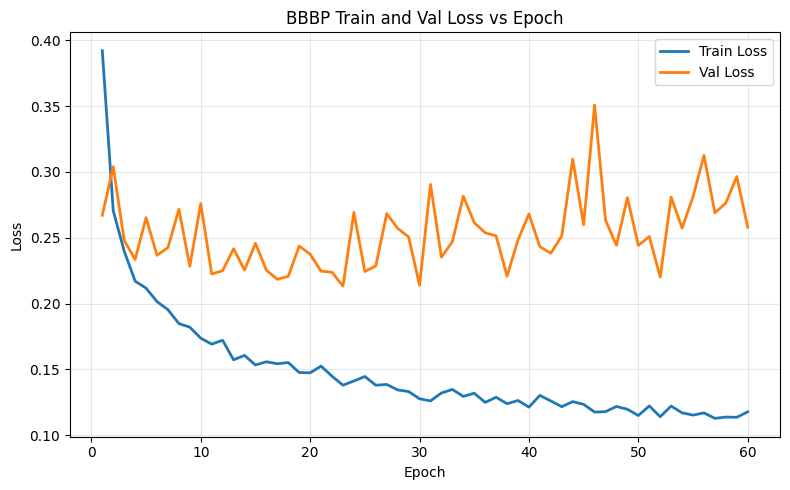

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 61/100, Epoch Accuracy: 95.7770
Train AUC-ROC: 0.9899, Train F1 Score: 0.9577 , Train Precision: 0.9674, Train Recall: 0.9482

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9784, Val F1 Score: 0.9167, Val Precision: 0.9228, Val Recall: 0.9106



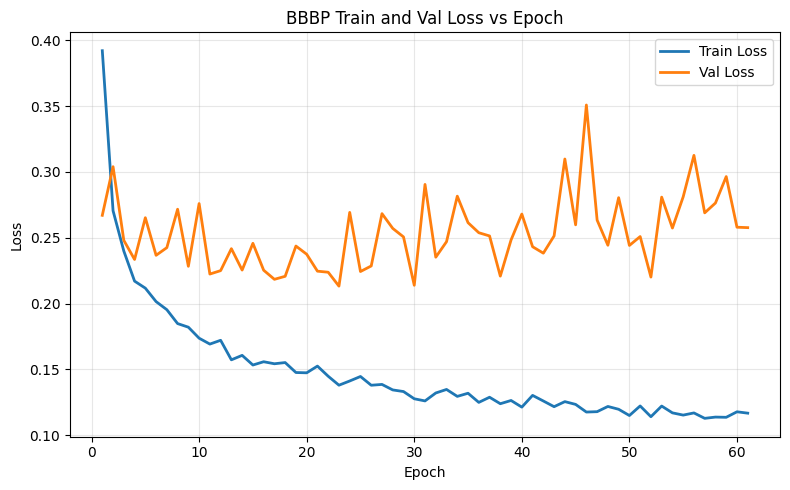

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 62/100, Epoch Accuracy: 95.9807
Train AUC-ROC: 0.9909, Train F1 Score: 0.9598 , Train Precision: 0.9672, Train Recall: 0.9526

Epoch Val Accuracy : 91.8333
Val AUC-ROC: 0.9805, Val F1 Score: 0.9187, Val Precision: 0.9203, Val Recall: 0.9172



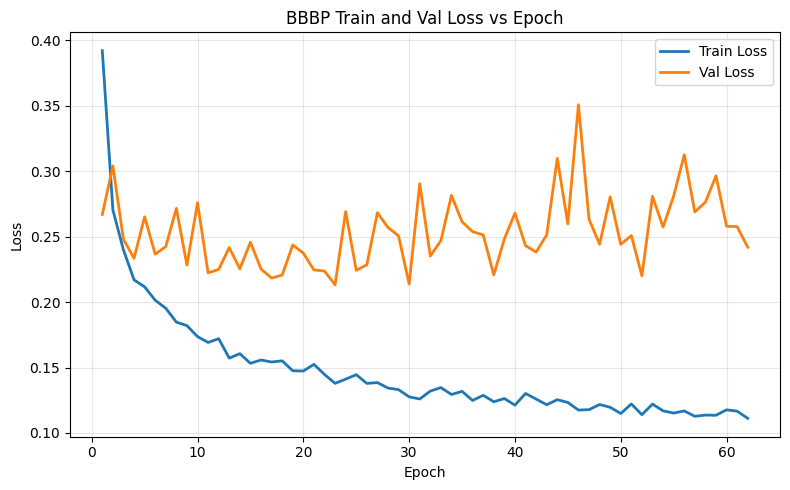

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 63/100, Epoch Accuracy: 95.9437
Train AUC-ROC: 0.9904, Train F1 Score: 0.9595 , Train Precision: 0.9661, Train Recall: 0.9530

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9784, Val F1 Score: 0.9203, Val Precision: 0.9233, Val Recall: 0.9172



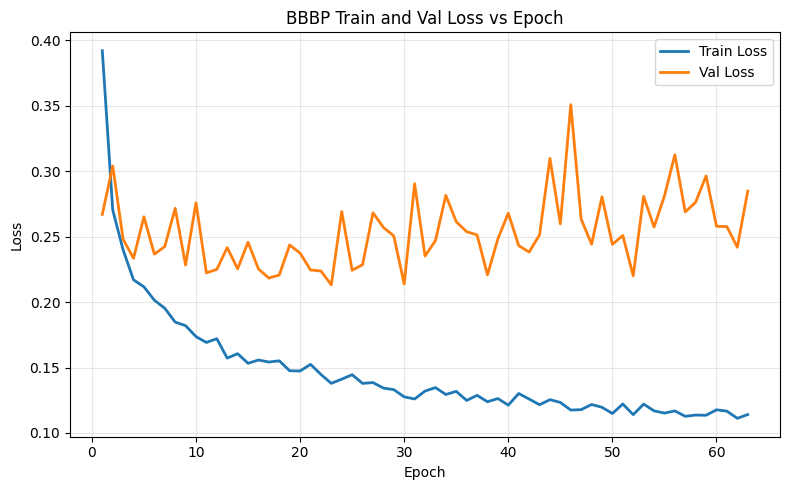

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 64/100, Epoch Accuracy: 95.8696
Train AUC-ROC: 0.9904, Train F1 Score: 0.9587 , Train Precision: 0.9674, Train Recall: 0.9500

Epoch Val Accuracy : 91.5000
Val AUC-ROC: 0.9804, Val F1 Score: 0.9154, Val Precision: 0.9169, Val Recall: 0.9139



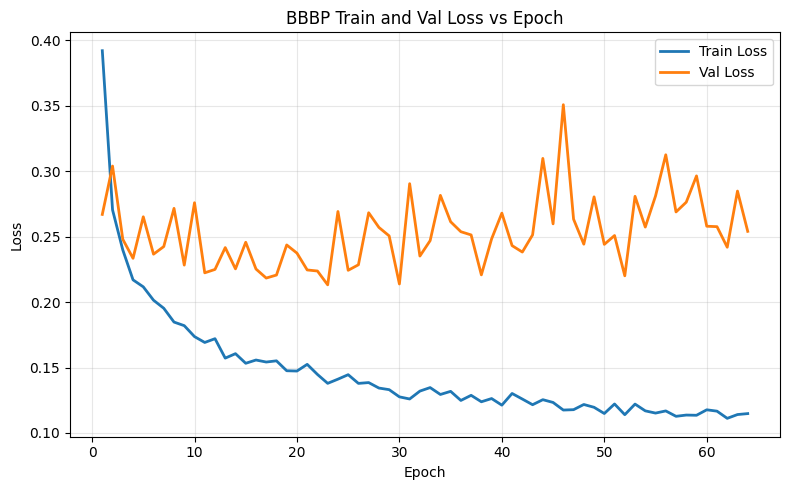

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 65/100, Epoch Accuracy: 95.8140
Train AUC-ROC: 0.9911, Train F1 Score: 0.9580 , Train Precision: 0.9685, Train Recall: 0.9478

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9790, Val F1 Score: 0.9211, Val Precision: 0.9150, Val Recall: 0.9272



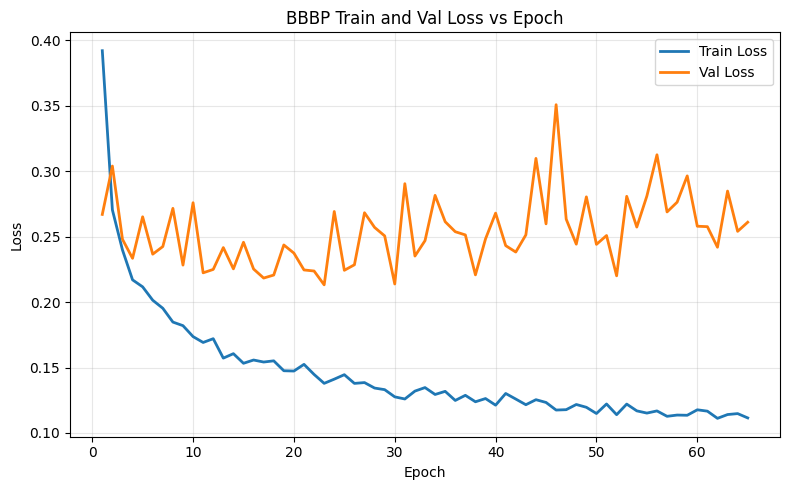

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 66/100, Epoch Accuracy: 95.7400
Train AUC-ROC: 0.9904, Train F1 Score: 0.9572 , Train Precision: 0.9695, Train Recall: 0.9452

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9814, Val F1 Score: 0.9226, Val Precision: 0.9180, Val Recall: 0.9272



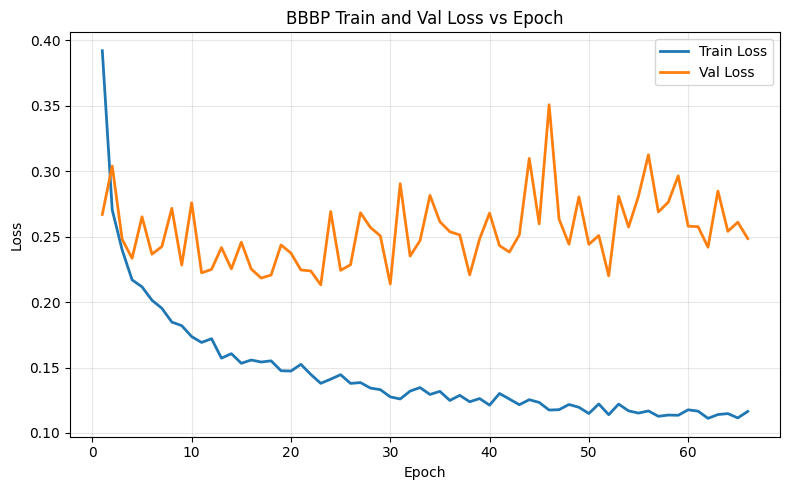

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 67/100, Epoch Accuracy: 96.1474
Saved model with accuracy train model with accuracy96.15% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_96.147.pth
Train AUC-ROC: 0.9905, Train F1 Score: 0.9613 , Train Precision: 0.9743, Train Recall: 0.9485

Epoch Val Accuracy : 92.5000
Val AUC-ROC: 0.9789, Val F1 Score: 0.9266, Val Precision: 0.9132, Val Recall: 0.9404

Saved best validation model from epoch 67 with validation accuracy 92.50% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_67_acc_92.500.pth


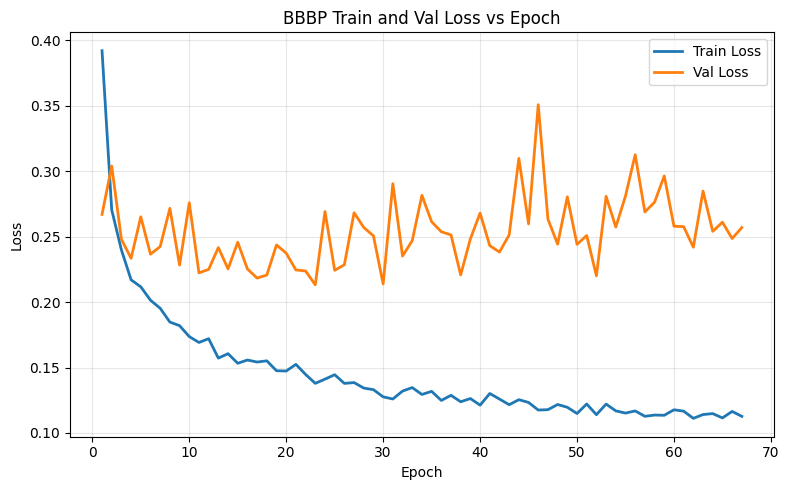

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 68/100, Epoch Accuracy: 95.9437
Train AUC-ROC: 0.9898, Train F1 Score: 0.9593 , Train Precision: 0.9696, Train Recall: 0.9493

Epoch Val Accuracy : 92.5000
Val AUC-ROC: 0.9802, Val F1 Score: 0.9259, Val Precision: 0.9213, Val Recall: 0.9305

Saved best validation model from epoch 68 with validation accuracy 92.50% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_68_acc_92.500.pth


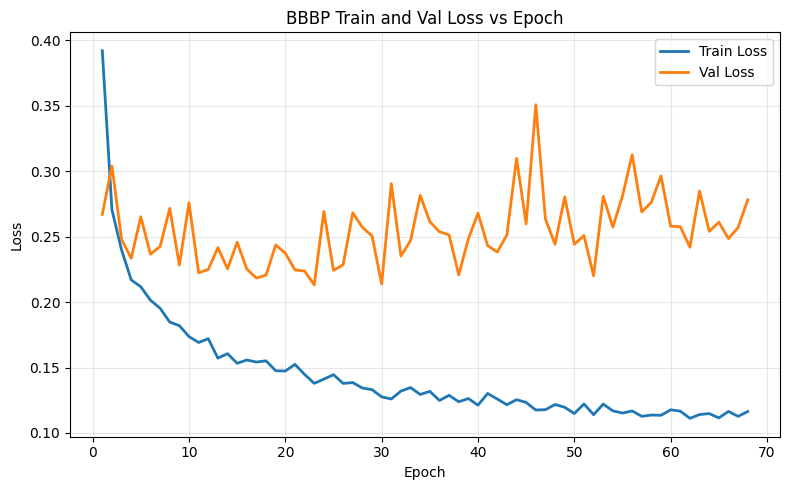

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 69/100, Epoch Accuracy: 95.7585
Train AUC-ROC: 0.9915, Train F1 Score: 0.9574 , Train Precision: 0.9695, Train Recall: 0.9456

Epoch Val Accuracy : 92.1667
Val AUC-ROC: 0.9799, Val F1 Score: 0.9226, Val Precision: 0.9180, Val Recall: 0.9272



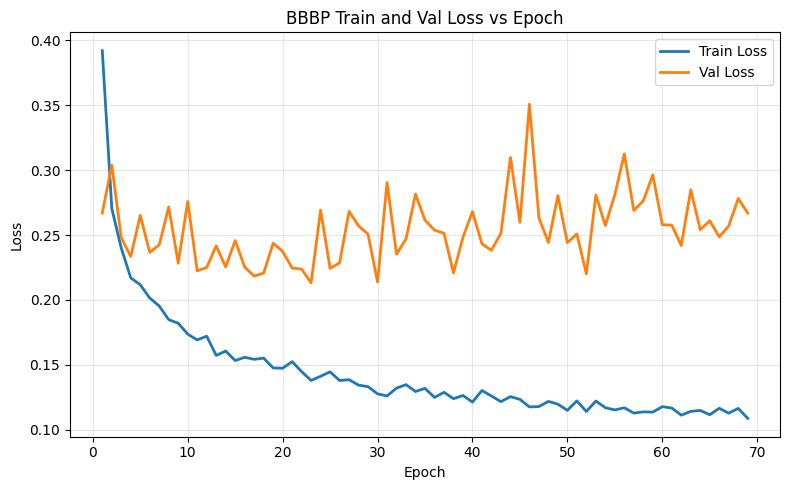

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 70/100, Epoch Accuracy: 96.0178
Train AUC-ROC: 0.9915, Train F1 Score: 0.9602 , Train Precision: 0.9668, Train Recall: 0.9537

Epoch Val Accuracy : 92.0000
Val AUC-ROC: 0.9786, Val F1 Score: 0.9211, Val Precision: 0.9150, Val Recall: 0.9272



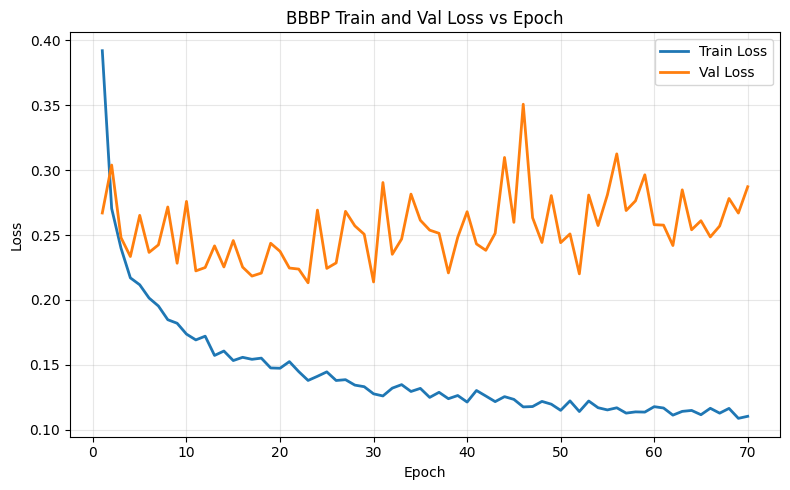

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 71/100, Epoch Accuracy: 96.0733
Train AUC-ROC: 0.9908, Train F1 Score: 0.9606 , Train Precision: 0.9714, Train Recall: 0.9500

Epoch Val Accuracy : 92.3333
Val AUC-ROC: 0.9802, Val F1 Score: 0.9243, Val Precision: 0.9183, Val Recall: 0.9305



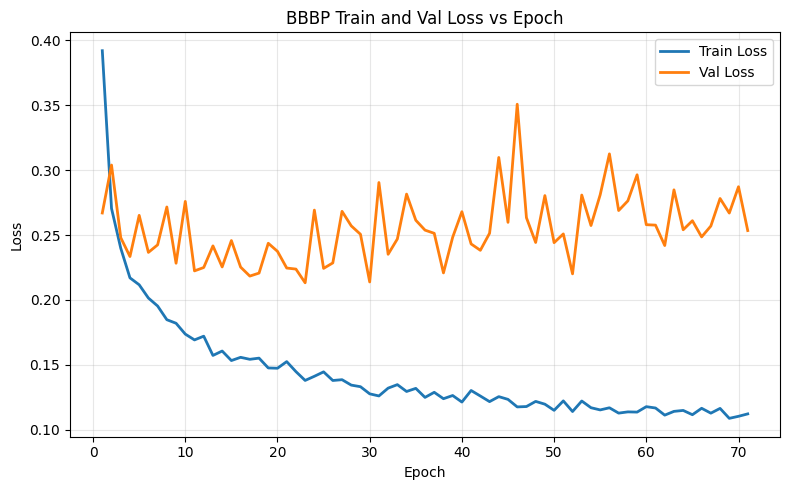

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 72/100, Epoch Accuracy: 96.0548
Train AUC-ROC: 0.9914, Train F1 Score: 0.9605 , Train Precision: 0.9686, Train Recall: 0.9526

Epoch Val Accuracy : 91.8333
Val AUC-ROC: 0.9794, Val F1 Score: 0.9193, Val Precision: 0.9148, Val Recall: 0.9238



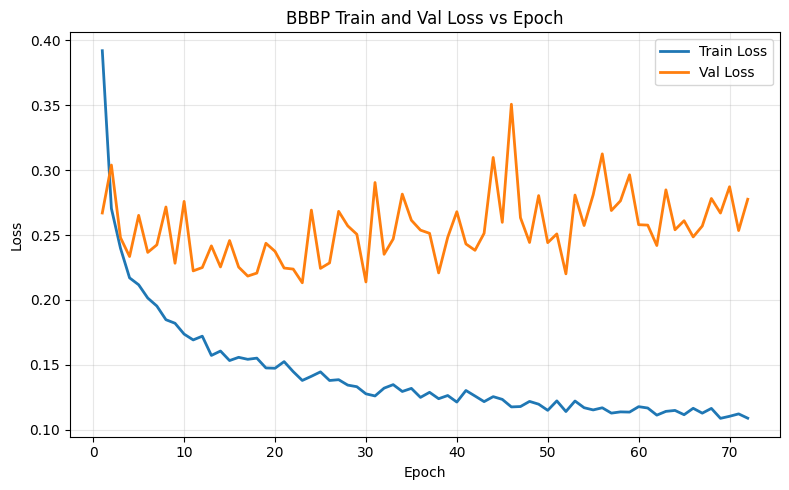

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 73/100, Epoch Accuracy: 96.3512
Saved model with accuracy train model with accuracy96.35% to saved_models/bbbp_2026-06-26_14-42-42/train_best_model_96.351.pth
Train AUC-ROC: 0.9906, Train F1 Score: 0.9634 , Train Precision: 0.9734, Train Recall: 0.9537

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9791, Val F1 Score: 0.9175, Val Precision: 0.9145, Val Recall: 0.9205



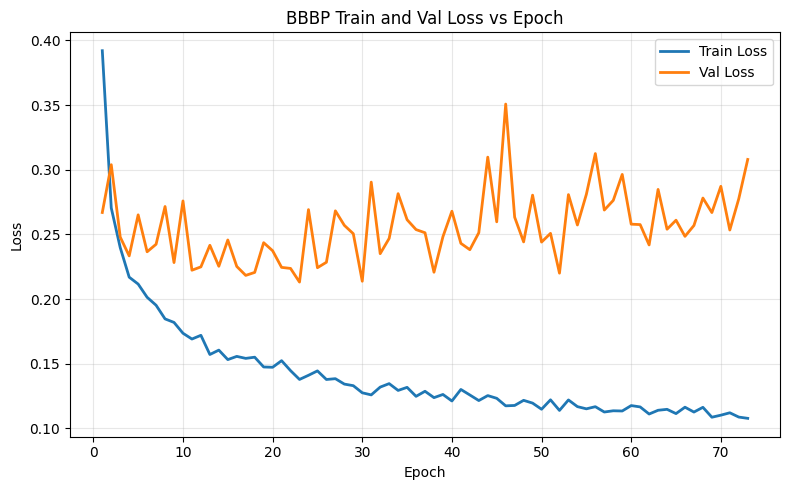

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 74/100, Epoch Accuracy: 96.3327
Train AUC-ROC: 0.9917, Train F1 Score: 0.9633 , Train Precision: 0.9712, Train Recall: 0.9555

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9783, Val F1 Score: 0.9186, Val Precision: 0.9038, Val Recall: 0.9338



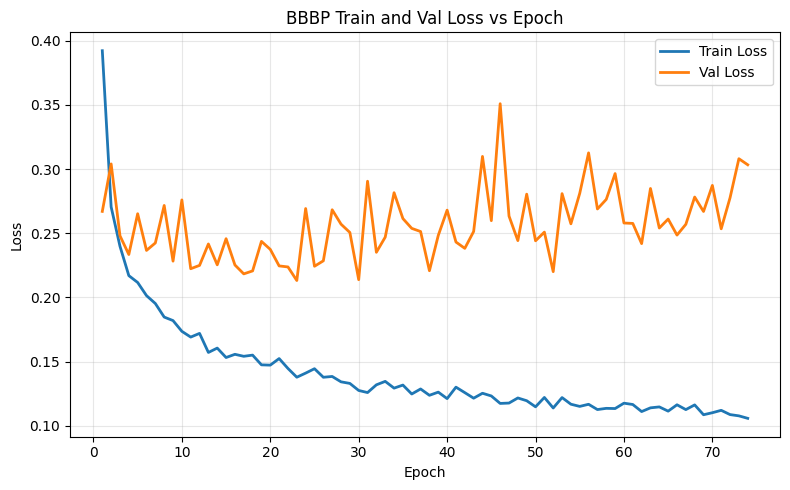

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 75/100, Epoch Accuracy: 96.1289
Train AUC-ROC: 0.9914, Train F1 Score: 0.9614 , Train Precision: 0.9666, Train Recall: 0.9563

Epoch Val Accuracy : 91.5000
Val AUC-ROC: 0.9795, Val F1 Score: 0.9173, Val Precision: 0.8984, Val Recall: 0.9371



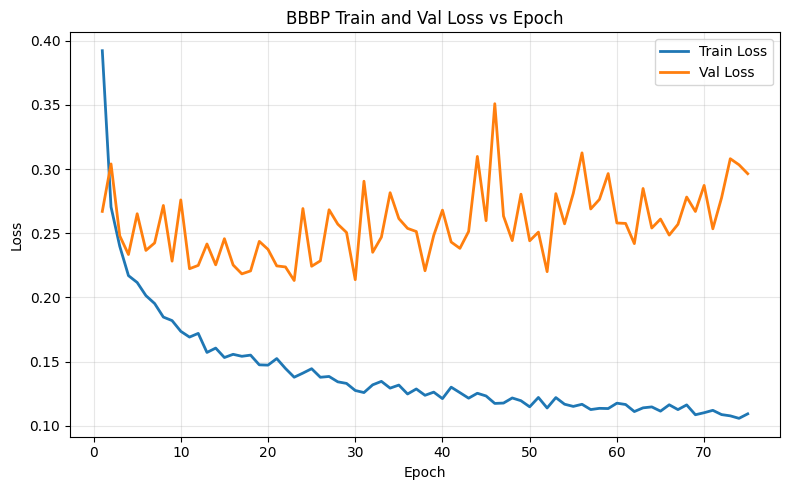

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 76/100, Epoch Accuracy: 96.1474
Train AUC-ROC: 0.9904, Train F1 Score: 0.9613 , Train Precision: 0.9729, Train Recall: 0.9500

Epoch Val Accuracy : 91.6667
Val AUC-ROC: 0.9795, Val F1 Score: 0.9186, Val Precision: 0.9038, Val Recall: 0.9338



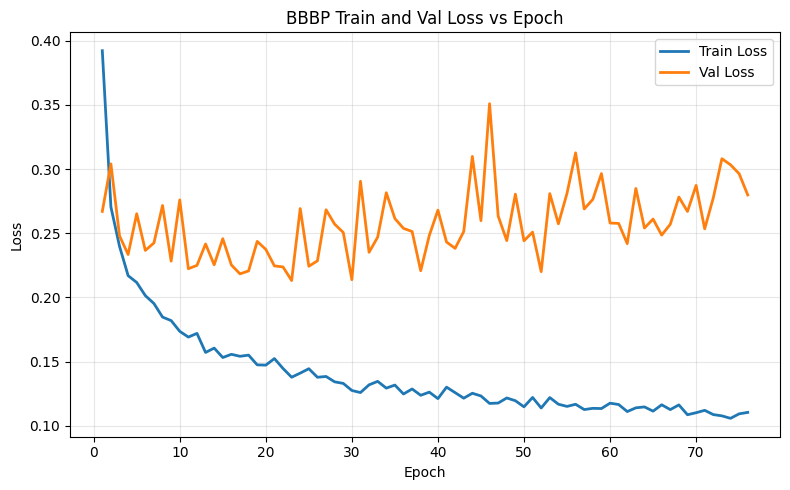

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 77/100, Epoch Accuracy: 95.9066
Train AUC-ROC: 0.9916, Train F1 Score: 0.9591 , Train Precision: 0.9664, Train Recall: 0.9519

Epoch Val Accuracy : 91.3333
Val AUC-ROC: 0.9792, Val F1 Score: 0.9167, Val Precision: 0.8882, Val Recall: 0.9470



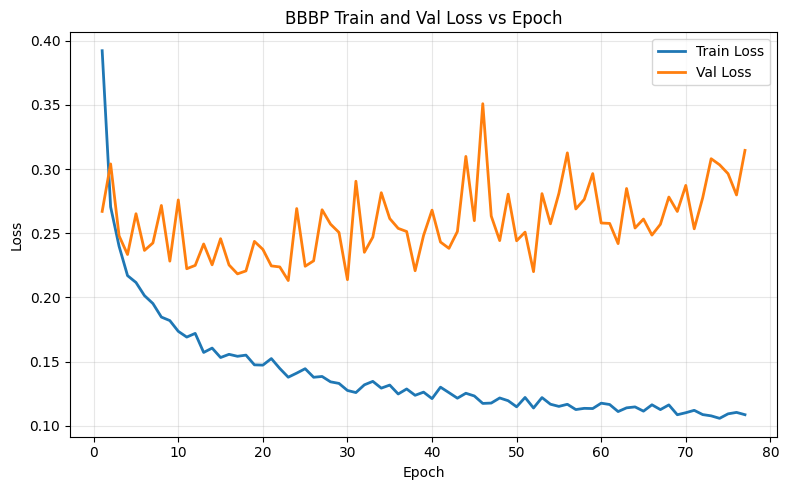

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png
Epoch 78/100, Epoch Accuracy: 96.1289
Train AUC-ROC: 0.9923, Train F1 Score: 0.9613 , Train Precision: 0.9680, Train Recall: 0.9548

Epoch Val Accuracy : 92.5000
Val AUC-ROC: 0.9796, Val F1 Score: 0.9251, Val Precision: 0.9298, Val Recall: 0.9205

Saved best validation model from epoch 78 with validation accuracy 92.50% to saved_models/bbbp_2026-06-26_14-42-42/val_best_model_epoch_78_acc_92.500.pth


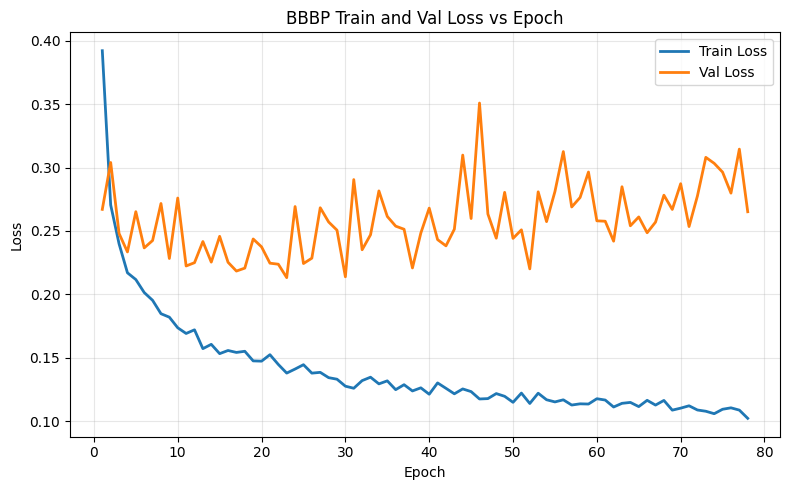

Train loss plot saved to: saved_models/bbbp_2026-06-26_14-42-42/bbbp_train_loss_plot.png


KeyboardInterrupt: 

In [ ]:
#main
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
from datetime import datetime
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
def analyze_component_roles(fusion_model, dataset, device, max_samples=100):

    fusion_model.eval()

    graph_norms = []
    smiles_norms = []
    fg_norms = []

    with torch.no_grad():

        for i, data_batch in enumerate(dataset):

            if i >= max_samples:
                break

            graph_data_batch = data_batch[0]
            sequence_inputs = data_batch[1].to(device)
            fg = data_batch[2]

            if len(fg.shape) == 1:
                fg = fg.unsqueeze(0)

            fg = fg.to(device)

            graph_emb = fusion_model.graph_model(graph_data_batch)
            smiles_emb = fusion_model.sequence_model(sequence_inputs)
            fg_emb = fusion_model.fg_encoder(fg)

            graph_norms.append(graph_emb.norm().item())
            smiles_norms.append(smiles_emb.norm().item())
            fg_norms.append(fg_emb.norm().item())

    print("\n===== Component Role Analysis =====")
    print(f"Graph Norm  : {np.mean(graph_norms):.4f}")
    print(f"SMILES Norm : {np.mean(smiles_norms):.4f}")
    print(f"FG Norm     : {np.mean(fg_norms):.4f}")

def main(data_name,options):
# 0 = Graph + SMILES
# 1 = Graph + FG
# 2 = Graph + SMILES + FG

    model_option = 2
    vocab_size = 100
    d_model = 128
    nhead = 4
    num_encoder_layers = 3
    dim_feedforward = 512
    max_length = 100
    batch_size = 1
    num_epochs = 100
    embed_dim = 128
    train_data, train_labels, val_data, val_labels, test_data, test_labels = load_data_long(data_name, device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu"))
    #train_data, train_labels, test_data, test_labels = load_data_long(data_name, device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu"))
    device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    #train_data, train_labels, test_data, test_labels = load_data_long(data_name, device)

    # convert train_labels to numpy
    train_labels_np = train_labels.cpu().numpy() if torch.is_tensor(train_labels) else train_labels
    test_labels_np = test_labels
    val_labels_np = val_labels# already numpy in your code

    print("Train:", np.bincount(train_labels_np.astype(int)))
    print("Test :", np.bincount(test_labels_np.astype(int)))
    input_dim_train = train_data['features'][0].size(-1)
    input_dim_test = test_data['features'][0].size(-1)


    adj_matrices_train = [adj_list_to_adj_matrix(adj_list) for adj_list in train_data['adj_lists']]
    adj_matrices_test = [adj_list_to_adj_matrix(adj_list) for adj_list in test_data['adj_lists']]
    adj_matrices_val = [adj_list_to_adj_matrix(adj_list) for adj_list in val_data['adj_lists']
]

    data_list_train = [Data(x=features.clone().detach(),
                              edge_index=torch.nonzero(adj_matrix, as_tuple=False).t().contiguous(),
                              y=torch.tensor(label, dtype=torch.float))
                         for features, adj_matrix, label in zip(train_data['features'], adj_matrices_train, train_labels)]
    data_list_test = [Data(x=features.clone().detach(),
                                edge_index=torch.nonzero(adj_matrix, as_tuple=False).t().contiguous(),
                                y=torch.tensor(label, dtype=torch.float))
                            for features, adj_matrix, label in zip(test_data['features'], adj_matrices_test, test_labels)]

    data_list_val = [Data(x=features.clone().detach(), edge_index=torch.nonzero(adj_matrix, as_tuple=False).t().contiguous(),
        y=torch.tensor(label, dtype=torch.float))
        for features, adj_matrix, label in zip(val_data['features'], adj_matrices_val, val_labels)]

    train_dataset = CustomDataset(data_list_train, train_data['sequence'], train_data['fg'])
    test_dataset = CustomDataset(data_list_test, test_data['sequence'], test_data['fg'])
    val_dataset = CustomDataset(data_list_val, val_data['sequence'], val_data['fg'])
    graph_model = Graph_Transformer(in_channels=input_dim_train, hidden_channels=64, embed_dim=embed_dim, heads=4).to(device)

    sequence_model = None
    fg_encoder = None

    if model_option in [0, 2]:
      sequence_model = TransformerModel(vocab_size, embed_dim, nhead, num_encoder_layers, dim_feedforward, max_length=100).to(device)

    if model_option in [1, 2]:
      fg_encoder = FunctionalGroupEmbedding(fg_input_dim=len(FUNCTIONAL_GROUPS), embed_dim=embed_dim).to(device)

    fusion_model = FusionModel(graph_model=graph_model, sequence_model=sequence_model, fg_encoder=fg_encoder, embed_dim=embed_dim, model_option=model_option).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(fusion_model.parameters(), lr=0.0001, weight_decay=5e-4)


    current_datetime = datetime.now()
    formatted_datetime = current_datetime.strftime('%Y-%m-%d_%H-%M-%S')
    session_name = f'{data_name}_{formatted_datetime}'
    folder_path = os.path.join('saved_models', session_name)
    os.makedirs(folder_path, exist_ok=True)

    output_dir_train = f'output/{data_name}/train'
    os.makedirs(output_dir_train, exist_ok=True)
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    file_name_train = f'{output_dir_train}/train_accuracy_details_{current_time}.txt'

    output_dir_test = f'output/{data_name}/test'
    os.makedirs(output_dir_test, exist_ok=True)
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    file_name_test = f'{output_dir_test}/test_accuracy_details_{current_time}.txt'


    best_train_accuracy = 0.0
    best_val_accuracy=0.0
    best_epoch = 0
    best_model_path = None
    # Training loop

    with open(file_name_train, 'a') as file_train, open(file_name_test, 'a') as file_test:
        train_losses = []
        test_losses = []
        for epoch in range(100):
            total_correct = 0
            total_samples = 0
            true_labels_train = []
            pred_probs_train = []
            losses=0.0


            for data_batch in train_dataset:
                graph_data_batch = data_batch[0]
                sequence_inputs  = data_batch[1]
                fg = data_batch[2]
                if len(fg.shape) == 1:
                  fg = fg.unsqueeze(0)
                fg = fg.to(device)
                sequence_targets=graph_data_batch.y

                # Zero the gradients
                optimizer.zero_grad()
                #graph_data = graph_data.to(device)
                sequence_inputs = sequence_inputs.to(device)
                fg = fg.to(device)

                # Forward pass
                output= fusion_model(graph_data_batch, sequence_inputs,fg)

                # Compute binary predictions
                prob = torch.sigmoid(output)
                binary_predictions = (prob >= 0.5).float()

                # Move and reshape sequence_targets BEFORE comparison
                sequence_targets = sequence_targets.view(-1, 1).to(device)

                # Compute batch accuracy
                batch_correct = (binary_predictions == sequence_targets).sum().item()
                total_samples += 1
                total_correct += batch_correct
                true_labels_train.append(sequence_targets.cpu().numpy().reshape(-1))
                pred_probs_train.append(prob.detach().cpu().numpy()[0])

                loss = criterion(output, sequence_targets)
                losses+=loss.item()

                # Backward pass
                loss.backward()

                # Update weights
                optimizer.step()


            avg_train_loss = losses / len(train_dataset)
            train_losses.append(avg_train_loss)
            # Compute epoch accuracy
            epoch_train_accuracy = (total_correct / total_samples)*100
            print(f"Epoch {epoch+1}/{100}, Epoch Accuracy: {epoch_train_accuracy:.4f}")

            if epoch_train_accuracy >= best_train_accuracy:
                best_train_accuracy = epoch_train_accuracy
                model_path = os.path.join(folder_path, f'train_best_model_{best_train_accuracy:.3f}.pth')
                torch.save(fusion_model.state_dict(), model_path)
                print("Saved model with accuracy train model with accuracy{:.2f}% to {}".format(best_train_accuracy, model_path))

            true_labels_train = np.concatenate(true_labels_train).astype(int) # Convert to int
            pred_probs_train = np.nan_to_num(np.concatenate(pred_probs_train), nan=0)
            predicted_labels_train_int = (pred_probs_train >= 0.5).astype(int)

            precision_train = precision_score(true_labels_train, predicted_labels_train_int)
            recall_train = recall_score(true_labels_train, predicted_labels_train_int)
            auc_roc_train = roc_auc_score(true_labels_train, pred_probs_train)
            f1_train = f1_score(true_labels_train, predicted_labels_train_int)
            print(f"Train AUC-ROC: {auc_roc_train:.4f}, Train F1 Score: {f1_train:.4f} , Train Precision: {precision_train:.4f}, Train Recall: {recall_train:.4f}\n")
            file_train.write(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {losses:.4f}, Train Accuracy: {epoch_train_accuracy:.4f}, Train AUC-ROC: {auc_roc_train:.4f}, Train F1 Score: {f1_train:.4f} , Train Precision: {precision_train:.4f}, Train Recall: {recall_train:.4f}\n')

            total_correct = 0
            total_samples = 0
            true_labels_val = []
            pred_probs_val = []
            test_loss = 0.0
            fusion_model.eval()

            with torch.no_grad():
                for data_batch in val_dataset:
                    graph_data_batch = data_batch[0]
                    sequence_inputs = data_batch[1]
                    fg = data_batch[2]

                    if len(fg.shape) == 1:
                        fg = fg.unsqueeze(0)

                    sequence_inputs = sequence_inputs.to(device)
                    fg = fg.to(device)
                    sequence_targets = graph_data_batch.y.view(-1, 1).to(device)

                    output = fusion_model(graph_data_batch, sequence_inputs, fg)
                    prob = torch.sigmoid(output)
                    binary_predictions = (prob >= 0.5).float()

                    batch_correct = (binary_predictions == sequence_targets).sum().item()

                    total_samples += 1
                    total_correct += batch_correct

                    true_labels_val.append(sequence_targets.cpu().numpy().reshape(-1))
                    pred_probs_val.append(prob.detach().cpu().numpy()[0])

                    loss = criterion(output, sequence_targets)
                    test_loss +=loss.item()
            avg_test_loss = test_loss / len(val_dataset)
            test_losses.append(avg_test_loss)
            epoch_val_accuracy = (total_correct / total_samples) * 100
            print(f"Epoch Val Accuracy : {epoch_val_accuracy:.4f}")

            true_labels_val = np.concatenate(true_labels_val).astype(int)
            pred_probs_val = np.nan_to_num(np.concatenate(pred_probs_val), nan=0)
            predicted_labels_val_int = (pred_probs_val >= 0.5).astype(int)

            precision_val = precision_score(true_labels_val, predicted_labels_val_int, zero_division=0)
            recall_val = recall_score(true_labels_val, predicted_labels_val_int, zero_division=0)
            auc_roc_val = roc_auc_score(true_labels_val, pred_probs_val)
            f1_val = f1_score(true_labels_val, predicted_labels_val_int, zero_division=0)

            print(
                f"Val AUC-ROC: {auc_roc_val:.4f}, "
                f"Val F1 Score: {f1_val:.4f}, "
                f"Val Precision: {precision_val:.4f}, "
                f"Val Recall: {recall_val:.4f}\n"
            )

            file_test.write(
                f'Epoch {epoch + 1}/{num_epochs}, '
                f'Val Accuracy: {epoch_val_accuracy:.4f}, '
                f'Val AUC-ROC: {auc_roc_val:.4f}, '
                f'Val F1 Score: {f1_val:.4f}, '
                f'Val Precision: {precision_val:.4f}, '
                f'Val Recall: {recall_val:.4f}\n'
            )
            #if avg_val_loss < best_val_loss:
            if epoch_val_accuracy >= best_val_accuracy:
                best_val_accuracy = epoch_val_accuracy
                best_epoch = epoch + 1

                best_model_path = os.path.join(
                    folder_path,
                    f'val_best_model_epoch_{best_epoch}_acc_{best_val_accuracy:.3f}.pth'
                )

                torch.save(fusion_model.state_dict(), best_model_path)

                print(
                    "Saved best validation model from epoch {} with validation accuracy {:.2f}% to {}".format(
                        best_epoch,
                        best_val_accuracy,
                        best_model_path
                    )
                )

            fusion_model.train()

            epochs = range(1, len(train_losses) + 1)
            plt.figure(figsize=(8, 5))
            #plt.plot(range(1, num_epochs + 1), train_losses, linewidth=2)
            plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
            plt.plot(epochs, test_losses, label="Val Loss", linewidth=2)
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"{data_name.upper()} Train and Val Loss vs Epoch")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()

            plot_path = os.path.join(folder_path, f"{data_name}_train_loss_plot.png")
            plt.savefig(plot_path, dpi=300)
            plt.show()

            print("Train loss plot saved to:", plot_path)

    print("\nTraining completed.")
    print("Best validation accuracy:", best_val_accuracy)
    print("Best epoch:", best_epoch)

    fusion_model.load_state_dict(torch.load(best_model_path))
    fusion_model.eval()

    total_correct = 0
    total_samples = 0
    true_labels_test = []
    pred_probs_test = []

    with torch.no_grad():
        for data_batch in test_dataset:
            graph_data_batch = data_batch[0]
            sequence_inputs = data_batch[1].to(device)
            fg = data_batch[2]

            if len(fg.shape) == 1:
                fg = fg.unsqueeze(0)

            fg = fg.to(device)

            sequence_targets = graph_data_batch.y.view(-1, 1).to(device)

            output = fusion_model(graph_data_batch, sequence_inputs, fg)
            prob = torch.sigmoid(output)

            binary_predictions = (prob >= 0.5).float()

            total_correct += (binary_predictions == sequence_targets).sum().item()
            total_samples += 1

            true_labels_test.append(sequence_targets.cpu().numpy().reshape(-1))
            pred_probs_test.append(prob.detach().cpu().numpy()[0])

    final_test_accuracy = (total_correct / total_samples) * 100

    true_labels_test = np.concatenate(true_labels_test).astype(int)
    pred_probs_test = np.nan_to_num(np.concatenate(pred_probs_test), nan=0)
    predicted_labels_test_int = (pred_probs_test >= 0.5).astype(int)

    precision_test = precision_score(true_labels_test, predicted_labels_test_int, zero_division=0)
    recall_test = recall_score(true_labels_test, predicted_labels_test_int, zero_division=0)
    auc_roc_test = roc_auc_score(true_labels_test, pred_probs_test)
    f1_test = f1_score(true_labels_test, predicted_labels_test_int, zero_division=0)

    print("\nFinal Test Performance")
    print(f"Test Accuracy: {final_test_accuracy:.4f}")
    print(f"Test AUC-ROC: {auc_roc_test:.4f}")
    print(f"Test F1 Score: {f1_test:.4f}")
    print(f"Test Precision: {precision_test:.4f}")
    print(f"Test Recall: {recall_test:.4f}")
    print("Pred counts:", np.bincount(predicted_labels_test_int))

    analyze_component_roles(fusion_model,test_dataset,device)

if __name__ == "__main__":
    options=[True,True,True,True]
    data_name='bbbp'
    main(data_name,options)






















































































































































































































































































































































































































